# Análise Completa do Modelo Híbrido LSTM-PINN
## Validação do Modelo Robusto e Fine-Tuned (2024)

Este notebook realiza análise completa:
1. Convergência do Treinamento Robusto
2. Desempenho do Modelo Generalista (2024)
3. Comparativo Generalista vs Especialistas
4. Visualizações 3D da Física Aprendida

## 1. Configuração e Imports

In [1]:
import sys
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D  
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch.utils.data import DataLoader, TensorDataset
from collections import OrderedDict

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100
sns.set_palette("husl")

sys.path.append(os.path.abspath(''))

from src.config import MODEL_CONFIG, DATA_CONFIG, PATHS, TRAINING_CONFIG
from src.model import DeepHestonHybrid, get_activation_function
from src.visualization import Visualizer
from src.data_loader import carregar_taxa_juros, carregar_ibov, _calcular_features_ativo

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")

Dispositivo: cuda


## 2. Funções Auxiliares

In [2]:
def criar_dataset_periodo(caminho_pasta_opcoes, df_juros, seq_length, data_stats, 
                          ano_inicio=None, ano_fim=None, lstm_input_size=10):
    """
    Cria dataset filtrando por período específico
    """
    lista_dfs = []
    df_ibov = carregar_ibov(PATHS.get('ibov_data', os.path.join(os.path.dirname(caminho_pasta_opcoes), 'BOVA11.csv')))
    
    print(f"Carregando dados de {ano_inicio if ano_inicio else 'todos os anos'}...")
    
    for arquivo in os.listdir(caminho_pasta_opcoes):
        if arquivo.endswith('.csv') and arquivo != "taxa_selic.csv":
            path_completo = os.path.join(caminho_pasta_opcoes, arquivo)
            try:
                df_temp = pd.read_csv(path_completo, sep=';', decimal=',', skiprows=1)
                if 'time' in df_temp.columns:
                    df_temp['time'] = pd.to_datetime(df_temp['time'], errors='coerce', utc=True).dt.tz_localize(None)
                
                if ano_inicio is not None:
                    df_temp = df_temp[df_temp['time'].dt.year >= ano_inicio]
                if ano_fim is not None:
                    df_temp = df_temp[df_temp['time'].dt.year <= ano_fim]
                    
                if df_temp.empty: 
                    continue

                if 'ativo' not in df_temp.columns:
                    df_temp['ativo'] = df_temp['symbol'].str[:4] if 'symbol' in df_temp.columns else 'UNKNOWN'
                
                cols_req = ['time', 'spot_price', 'strike', 'premium', 'days_to_maturity', 'ativo']
                if all(c in df_temp.columns for c in cols_req):
                    lista_dfs.append(df_temp[cols_req])
            except Exception:
                continue

    if not lista_dfs:
        print("Nenhum dado encontrado")
        return None

    df_full = pd.concat(lista_dfs, ignore_index=True)
    df_full = df_full[df_full['premium'] > 0.0]
    df_full['data_only'] = df_full['time'].dt.normalize()
    
    if df_juros is not None:
        df_full = pd.merge(df_full, df_juros, on='data_only', how='left')
        df_full['r'] = df_full['r'].ffill().bfill().fillna(0.10)
    else:
        df_full['r'] = 0.10
    
    df_full['Dividend_Yield'] = 0.0 

    if df_ibov is not None:
        df_full = pd.merge(df_full, df_ibov, on='data_only', how='left')
        df_full['log_ret_ibov'] = df_full['log_ret_ibov'].fillna(0.0)
    else:
        df_full['log_ret_ibov'] = 0.0

    asset_map = data_stats['asset_map']
    sequences, pinn_inputs, targets, timestamps, asset_ids_list, weights_list = [], [], [], [], [], []
    
    print("Gerando sequências...")
    for nome_ativo, df_grupo in df_full.groupby('ativo'):
        if nome_ativo not in asset_map: 
            continue
        
        asset_id = asset_map[nome_ativo]
        df_grupo = df_grupo.sort_values('time')
        
        df_asset = df_grupo[['time', 'spot_price']].drop_duplicates('time').copy()
        if len(df_asset) < seq_length: 
            continue
        
        df_asset = _calcular_features_ativo(df_asset)
        df_asset['data_only'] = df_asset['time'].dt.normalize()
        
        if df_ibov is not None:
            df_asset = pd.merge(df_asset, df_ibov, on='data_only', how='left')
            df_asset['log_ret_ibov'] = df_asset['log_ret_ibov'].fillna(0.0)
        else:
            df_asset['log_ret_ibov'] = 0.0
        
        cols_lstm_base = ['log_ret', 'rolling_vol_20', 'ewma_vol', 'vol_parkinson', 'log_vol_fin', 'log_ret_ibov']
        
        for c in cols_lstm_base:
            if c not in df_asset.columns: 
                df_asset[c] = 0.0
        
        df_asset['rolling_vol_10'] = df_asset['rolling_vol_20'].rolling(10, min_periods=1).mean()
        df_asset['log_ret_squared'] = df_asset['log_ret'] ** 2
        df_asset['vol_ratio'] = df_asset['rolling_vol_20'] / (df_asset['ewma_vol'] + 1e-8)
        df_asset['ibov_vol_ratio'] = df_asset['log_ret_ibov'].abs().rolling(20, min_periods=1).mean()
        
        if lstm_input_size == 10:
            cols_lstm = cols_lstm_base + ['rolling_vol_10', 'log_ret_squared', 'vol_ratio', 'ibov_vol_ratio']
        else:
            cols_lstm = cols_lstm_base[:lstm_input_size]
            
        asset_feats = df_asset[cols_lstm].values.astype(np.float32)
        asset_dates = df_asset['time'].tolist()
        date_map = {ts: i for i, ts in enumerate(asset_dates)}
        
        for row in df_grupo.itertuples():
            idx = date_map.get(row.time)
            if idx is not None and idx >= seq_length:
                sequences.append(asset_feats[idx-seq_length : idx])
                pinn_inputs.append([row.spot_price, row.strike, row.days_to_maturity/252.0, row.r, row.Dividend_Yield])
                targets.append(row.premium)
                timestamps.append(row.time.timestamp())
                asset_ids_list.append(asset_id)
                weights_list.append(1.0)

    if not targets: 
        return None

    X_seq = np.array(sequences, dtype=np.float32)
    X_phy = np.array(pinn_inputs, dtype=np.float32)
    y = np.array(targets, dtype=np.float32).reshape(-1, 1)
    y_norm = y / (X_phy[:, 1:2] + 1e-8)
    
    X_phy[:, 0] = (X_phy[:, 0] - data_stats['S_mean']) / (data_stats['S_std'] + 1e-8)
    X_phy[:, 1] = (X_phy[:, 1] - data_stats['K_mean']) / (data_stats['K_std'] + 1e-8)
    X_phy[:, 2] = (X_phy[:, 2] - data_stats['T_mean']) / (data_stats['T_std'] + 1e-8)
    X_phy[:, 3] = (X_phy[:, 3] - data_stats['r_mean']) / (data_stats['r_std'] + 1e-8)
    X_phy[:, 4] = (X_phy[:, 4] - data_stats['q_mean']) / (data_stats['q_std'] + 1e-8)

    print(f"Dataset: {len(y)} amostras, {X_seq.shape[2]} features LSTM")
    return TensorDataset(
        torch.from_numpy(X_seq), torch.from_numpy(X_phy), torch.from_numpy(y_norm),
        torch.from_numpy(np.array(timestamps, dtype=np.float64).reshape(-1,1)), 
        torch.from_numpy(np.array(weights_list, dtype=np.float32).reshape(-1,1)), 
        torch.from_numpy(np.array(asset_ids_list, dtype=np.int64))
    )

def load_adaptive_model(model_class, config, data_stats, checkpoint_path, device):
    """
    Carrega modelo adaptando arquitetura ao checkpoint
    """
    print(f"Carregando: {checkpoint_path}")
    state_dict = torch.load(checkpoint_path, map_location=device)
    
    if 'lstm.weight_ih_l0' in state_dict:
        weight_ih = state_dict['lstm.weight_ih_l0']
        ckpt_input_size = weight_ih.shape[1]
        print(f"LSTM input_size detectado: {ckpt_input_size}")
        config['lstm_input_size'] = ckpt_input_size
        if ckpt_input_size == 10:
            config['use_asset_embeddings'] = False
    
    model = model_class(config, data_stats)
    
    if 'fourier_layer.weight' in state_dict:
        fourier_w = state_dict['fourier_layer.weight']
        out_features, in_features = fourier_w.shape
        model.fourier_layer = torch.nn.Linear(in_features, out_features)
    
    from src.model import AdaptiveActivation
    activation_fn = get_activation_function(config.get('activation', 'tanh'))
    
    layer_indices = sorted([int(k.split('.')[1]) for k in state_dict.keys() if 'pricing_net' in k and 'weight' in k])
    
    if layer_indices:
        layers = OrderedDict()
        for i, idx in enumerate(layer_indices):
            weight_key = f'pricing_net.{idx}.weight'
            w_shape = state_dict[weight_key].shape
            layers[str(idx)] = torch.nn.Linear(in_features=w_shape[1], out_features=w_shape[0])
            if i < len(layer_indices) - 1:
                act_key = f'pricing_net.{idx+1}.a'
                if act_key in state_dict:
                    layers[str(idx+1)] = AdaptiveActivation(activation_fn)
        model.pricing_net = torch.nn.Sequential(layers)
    
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    model = model.to(device)
    model.eval()
    print("Modelo carregado com sucesso")
    return model

def calcular_metricas(y_true, y_pred):
    """
    Calcula métricas estatísticas
    """
    metrics = {}
    metrics['MAE'] = mean_absolute_error(y_true, y_pred)
    metrics['RMSE'] = np.sqrt(mean_squared_error(y_true, y_pred))
    metrics['R2'] = r2_score(y_true, y_pred)
    errors = np.abs(y_true - y_pred)
    metrics['MAPE'] = np.mean(errors / (np.abs(y_true) + 1e-8)) * 100
    metrics['Erro_Medio'] = np.mean(y_pred - y_true)
    metrics['Std_Erro'] = np.std(y_pred - y_true)
    return metrics

def avaliar_modelo(model, loader, data_stats, device, model_name="Modelo"):
    """
    Avalia modelo em dataset
    """
    model.eval()
    all_predictions, all_targets, all_vols = [], [], []
    
    with torch.no_grad():
        for batch in loader:
            x_seq, x_phy, y_norm, _, _, ids = [b.to(device) for b in batch]
            outputs = model(x_seq, x_phy, ids)
            K_real = x_phy[:, 1:2] * data_stats['K_std'] + data_stats['K_mean']
            price_pred = outputs['price'] * K_real
            price_real = y_norm * K_real
            all_predictions.extend(price_pred.cpu().numpy().flatten())
            all_targets.extend(price_real.cpu().numpy().flatten())
            if 'volatility' in outputs:
                all_vols.extend(outputs['volatility'].cpu().numpy().flatten())
    
    all_predictions = np.array(all_predictions)
    all_targets = np.array(all_targets)
    metrics = calcular_metricas(all_targets, all_predictions)
    
    print(f"\n{'='*60}")
    print(f"AVALIAÇÃO: {model_name}")
    print(f"{'='*60}")
    print(f"Amostras: {len(all_targets):,}")
    print(f"MAE: {metrics['MAE']:.4f}")
    print(f"RMSE: {metrics['RMSE']:.4f}")
    print(f"R²: {metrics['R2']:.4f}")
    print(f"MAPE: {metrics['MAPE']:.2f}%")
    
    return {'predictions': all_predictions, 'targets': all_targets, 
            'volatilities': np.array(all_vols) if all_vols else None, 'metrics': metrics}

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import numpy as np

def enriquecer_resultados(loader, results_dict, data_stats, device):
    """
    Adiciona Moneyness, Maturidade e Timestamps ao dicionário de resultados
    para permitir visualizações avançadas.
    """
    all_S, all_K, all_T, all_times = [], [], [], []
    
    # Iterar novamente pelo loader para pegar os inputs (sem recalcular o modelo)
    for batch in loader:
        _, x_phy, _, timestamps, _, _ = batch
        
        # Desnormalizar dados físicos (baseado na função criar_dataset_periodo)
        S = x_phy[:, 0] * data_stats['S_std'] + data_stats['S_mean']
        K = x_phy[:, 1] * data_stats['K_std'] + data_stats['K_mean']
        T = x_phy[:, 2] * data_stats['T_std'] + data_stats['T_mean']
        
        all_S.extend(S.cpu().numpy())
        all_K.extend(K.cpu().numpy())
        all_T.extend(T.cpu().numpy())
        all_times.extend(timestamps.numpy().flatten())

    # Converter para arrays
    S = np.array(all_S)
    K = np.array(all_K)
    T = np.array(all_T)
    
    # Adicionar ao dicionário
    results_dict['moneyness'] = S / (K + 1e-8)
    results_dict['maturity'] = T
    results_dict['strike'] = K
    results_dict['spot'] = S
    results_dict['timestamps'] = pd.to_datetime(np.array(all_times), unit='s')
    
    return results_dict

# ATUALIZAR SEUS RESULTADOS (Execute isso para o modelo Generalista)
if 'results_gen' in locals() and 'loader_2024' in locals():
    print("Enriquecendo dados do modelo Generalista...")
    results_gen = enriquecer_resultados(loader_2024, results_gen, data_stats, device)

## 3. Análise do Histórico de Treinamento

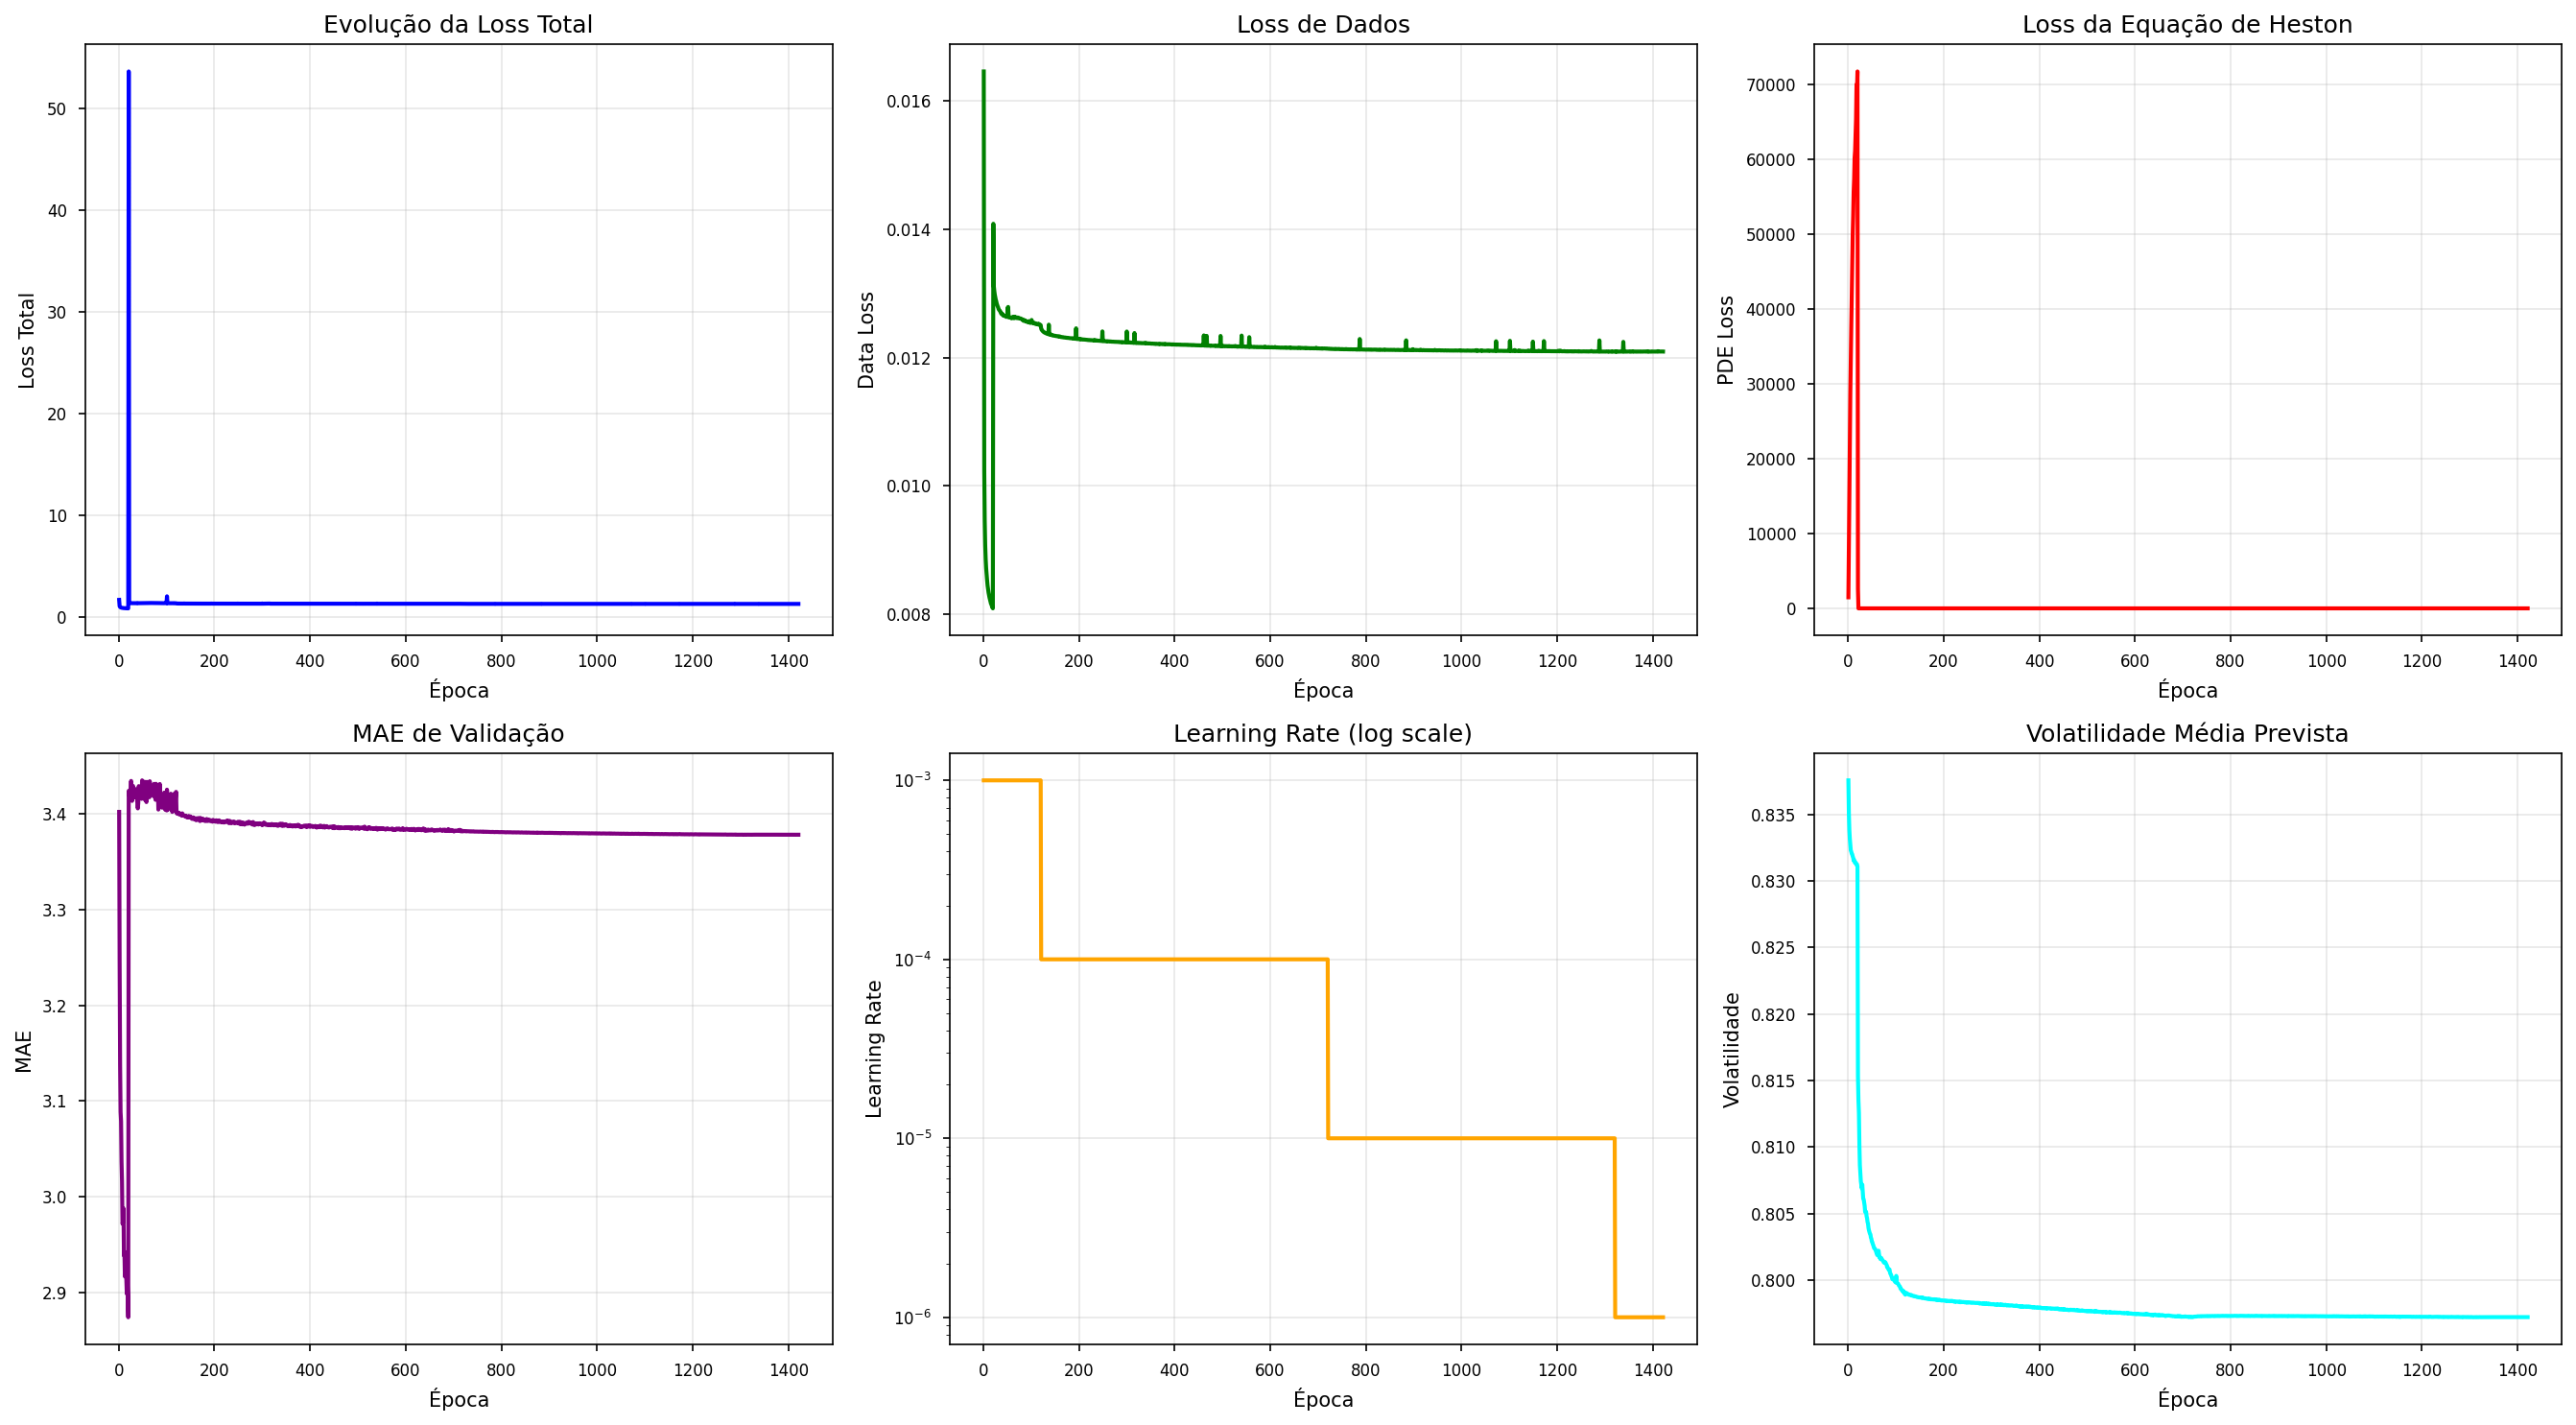


Total de épocas: 1421
Loss final: 1.249120
MAE final: 3.378413


In [4]:
history_path = os.path.join(PATHS['results_dir'], 'training_history.csv')

if os.path.exists(history_path):
    history_df = pd.read_csv(history_path)
    history_df['epoch'] = range(1, len(history_df) + 1)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    axes[0, 0].plot(history_df['epoch'], history_df['train_loss'], 'b-', linewidth=2)
    axes[0, 0].set_xlabel('Época')
    axes[0, 0].set_ylabel('Loss Total')
    axes[0, 0].set_title('Evolução da Loss Total')
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].plot(history_df['epoch'], history_df['loss_data'], 'g-', linewidth=2)
    axes[0, 1].set_xlabel('Época')
    axes[0, 1].set_ylabel('Data Loss')
    axes[0, 1].set_title('Loss de Dados')
    axes[0, 1].grid(True, alpha=0.3)
    
    axes[0, 2].plot(history_df['epoch'], history_df['loss_pde'], 'r-', linewidth=2)
    axes[0, 2].set_xlabel('Época')
    axes[0, 2].set_ylabel('PDE Loss')
    axes[0, 2].set_title('Loss da Equação de Heston')
    axes[0, 2].grid(True, alpha=0.3)
    
    axes[1, 0].plot(history_df['epoch'], history_df['val_mae'], 'purple', linewidth=2)
    axes[1, 0].set_xlabel('Época')
    axes[1, 0].set_ylabel('MAE')
    axes[1, 0].set_title('MAE de Validação')
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].plot(history_df['epoch'], history_df['lr'], 'orange', linewidth=2)
    axes[1, 1].set_xlabel('Época')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].set_title('Learning Rate (log scale)')
    axes[1, 1].set_yscale('log')
    axes[1, 1].grid(True, alpha=0.3)
    
    if 'avg_pred_vol' in history_df.columns:
        axes[1, 2].plot(history_df['epoch'], history_df['avg_pred_vol'], 'cyan', linewidth=2)
        axes[1, 2].set_xlabel('Época')
        axes[1, 2].set_ylabel('Volatilidade')
        axes[1, 2].set_title('Volatilidade Média Prevista')
        axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nTotal de épocas: {len(history_df)}")
    print(f"Loss final: {history_df['train_loss'].iloc[-1]:.6f}")
    print(f"MAE final: {history_df['val_mae'].iloc[-1]:.6f}")
else:
    print("Histórico de treinamento não encontrado")

## 4. Carregamento e Avaliação do Modelo Generalista

In [5]:
stats_path = os.path.join(PATHS['model_save_dir'], 'data_stats.json')
with open(stats_path, 'r') as f:
    data_stats = json.load(f)

MODEL_CONFIG['num_assets'] = len(data_stats['asset_map'])
print(f"Ativos: {MODEL_CONFIG['num_assets']}")
print(f"Mapa: {list(data_stats['asset_map'].keys())}")

weights_path = os.path.join(PATHS['model_save_dir'], 'best_model_weights.pth')
state_dict = torch.load(weights_path, map_location=device)

if 'lstm.weight_ih_l0' in state_dict:
    weight_ih = state_dict['lstm.weight_ih_l0']
    lstm_input_size = weight_ih.shape[1]
    print(f"Input size: {lstm_input_size}")
else:
    lstm_input_size = MODEL_CONFIG.get('lstm_input_size', 6)

df_juros = carregar_taxa_juros(PATHS['selic_data'])
pasta_dados = PATHS['raw_data']

print("\nCriando datasets...")
ds_treino = criar_dataset_periodo(pasta_dados, df_juros, DATA_CONFIG['sequence_length'], 
                                  data_stats, 2020, 2023, lstm_input_size)
ds_2024 = criar_dataset_periodo(pasta_dados, df_juros, DATA_CONFIG['sequence_length'],
                               data_stats, 2024, 2024, lstm_input_size)

if ds_treino and ds_2024:
    print(f"\nTreino (2020-2023): {len(ds_treino):,}")
    print(f"Validação (2024): {len(ds_2024):,}")
    
    model_generalista = load_adaptive_model(DeepHestonHybrid, MODEL_CONFIG, data_stats, weights_path, device)
    
    loader_2024 = DataLoader(ds_2024, batch_size=512, shuffle=False)
    results_gen = avaliar_modelo(model_generalista, loader_2024, data_stats, device, "Generalista 2024")
else:
    print("Erro ao criar datasets")

Ativos: 14
Mapa: ['ABEV', 'B3SA', 'BBAS', 'BBDC', 'BOVA', 'CSNA', 'GGBR', 'ITUB', 'LREN', 'MGLU', 'PETR', 'SUZB', 'VALE', 'WEGE']
Input size: 10

Criando datasets...
[INFO] IBOV carregado com sucesso: 443085 registros, coluna de preço: acao_close_ajustado
Carregando dados de 2020...
Gerando sequências...
Dataset: 2277735 amostras, 10 features LSTM
[INFO] IBOV carregado com sucesso: 443085 registros, coluna de preço: acao_close_ajustado
Carregando dados de 2024...
Gerando sequências...
Dataset: 736451 amostras, 10 features LSTM

Treino (2020-2023): 2,277,735
Validação (2024): 736,451
Carregando: d:\UERJ\Programacao_e_Codigos\PINN_Opcoes_BR\resultados\modelo_final\best_model_weights.pth
LSTM input_size detectado: 10
Modelo carregado com sucesso

AVALIAÇÃO: Generalista 2024
Amostras: 736,451
MAE: 5.1418
RMSE: 11.5865
R²: -1.0894
MAPE: 6844.69%


## 5. Visualizações do Modelo Generalista

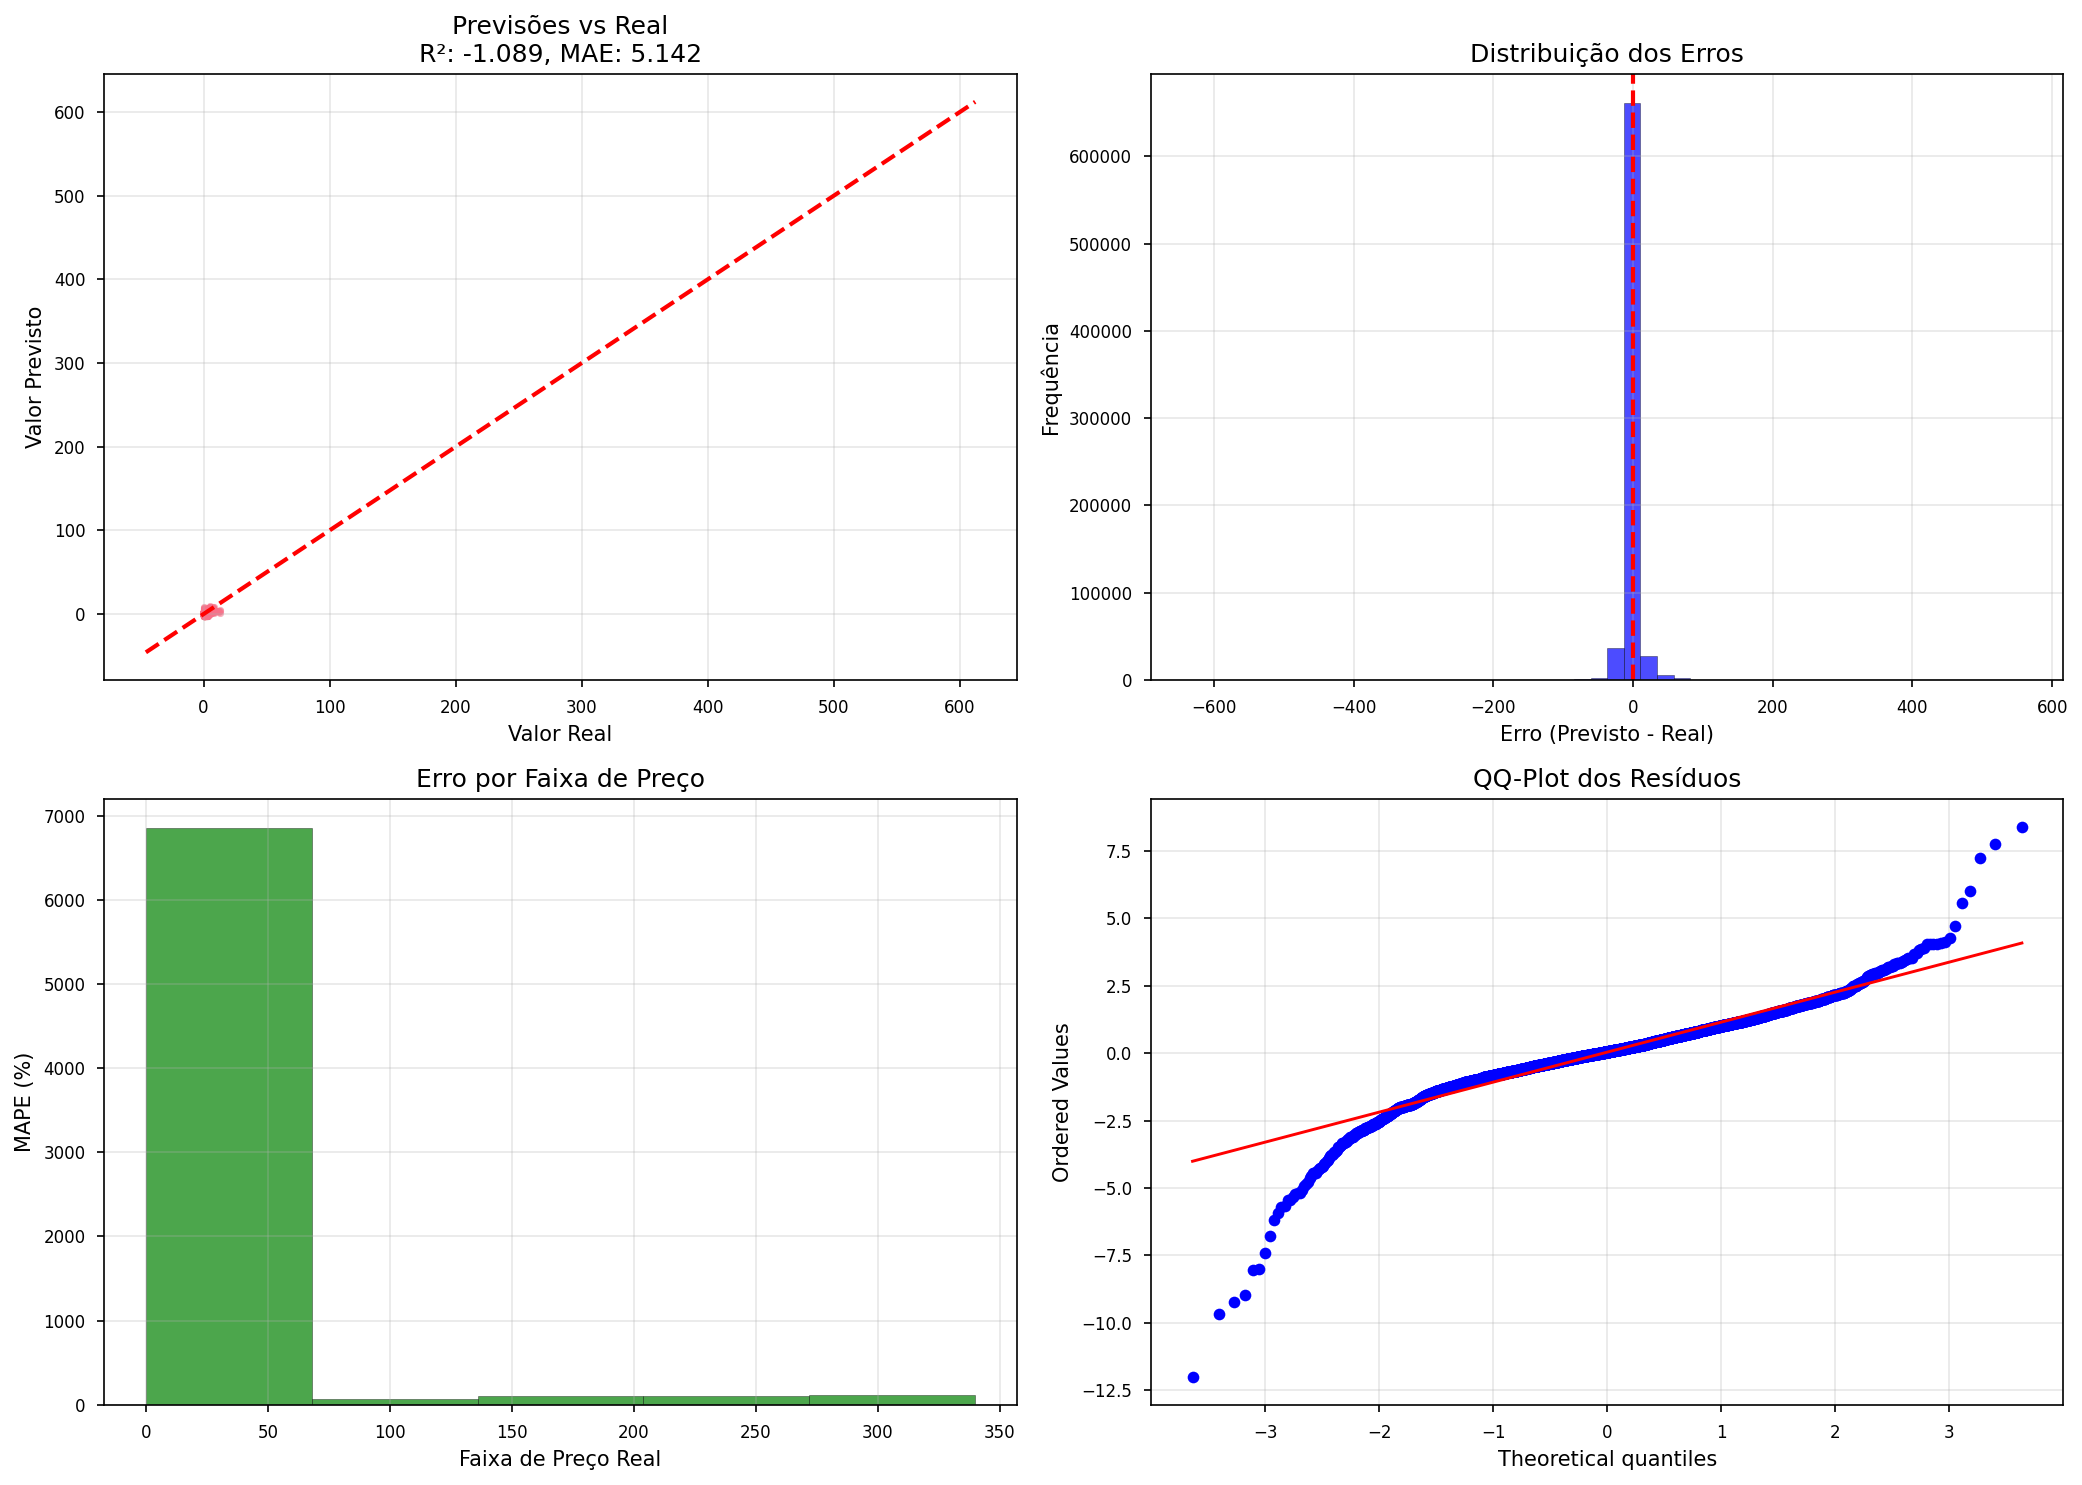

In [6]:
if 'results_gen' in locals():
    predictions = results_gen['predictions']
    targets = results_gen['targets']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    axes[0, 0].scatter(targets[:5000], predictions[:5000], alpha=0.5, s=10)
    max_val = max(targets.max(), predictions.max())
    min_val = min(targets.min(), predictions.min())
    axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    axes[0, 0].set_xlabel('Valor Real')
    axes[0, 0].set_ylabel('Valor Previsto')
    axes[0, 0].set_title(f'Previsões vs Real\nR²: {results_gen["metrics"]["R2"]:.3f}, MAE: {results_gen["metrics"]["MAE"]:.3f}')
    axes[0, 0].grid(True, alpha=0.3)
    
    errors = predictions - targets
    axes[0, 1].hist(errors, bins=50, alpha=0.7, color='blue', edgecolor='black')
    axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[0, 1].set_xlabel('Erro (Previsto - Real)')
    axes[0, 1].set_ylabel('Frequência')
    axes[0, 1].set_title('Distribuição dos Erros')
    axes[0, 1].grid(True, alpha=0.3)
    
    price_bins = np.linspace(targets.min(), targets.max(), 10)
    bin_errors, bin_centers = [], []
    for i in range(len(price_bins)-1):
        mask = (targets >= price_bins[i]) & (targets < price_bins[i+1])
        if mask.sum() > 0:
            bin_errors.append(np.mean(np.abs(errors[mask]) / (targets[mask] + 1e-8)) * 100)
            bin_centers.append((price_bins[i] + price_bins[i+1]) / 2)
    
    axes[1, 0].bar(bin_centers, bin_errors, width=price_bins[1]-price_bins[0], alpha=0.7, color='green', edgecolor='black')
    axes[1, 0].set_xlabel('Faixa de Preço Real')
    axes[1, 0].set_ylabel('MAPE (%)')
    axes[1, 0].set_title('Erro por Faixa de Preço')
    axes[1, 0].grid(True, alpha=0.3)
    
    import scipy.stats as stats
    stats.probplot(errors[:5000], dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title('QQ-Plot dos Resíduos')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 6. Avaliação dos Modelos Fine-Tuned

Modelos fine-tuned encontrados: 14
Ativos: ['ABEV', 'B3SA', 'BBAS', 'BBDC', 'BOVA', 'CSNA', 'GGBR', 'ITUB', 'LREN', 'MGLU', 'PETR', 'SUZB', 'VALE', 'WEGE']
Carregando: d:\UERJ\Programacao_e_Codigos\PINN_Opcoes_BR\resultados\modelo_final\best_ABEV.pt
LSTM input_size detectado: 10
Modelo carregado com sucesso

AVALIAÇÃO: Fine-tuned ABEV
Amostras: 736,451
MAE: 5.1056
RMSE: 11.5296
R²: -1.0690
MAPE: 6822.71%
Carregando: d:\UERJ\Programacao_e_Codigos\PINN_Opcoes_BR\resultados\modelo_final\best_B3SA.pt
LSTM input_size detectado: 10
Modelo carregado com sucesso

AVALIAÇÃO: Fine-tuned B3SA
Amostras: 736,451
MAE: 5.1204
RMSE: 11.5328
R²: -1.0701
MAPE: 6829.55%
Carregando: d:\UERJ\Programacao_e_Codigos\PINN_Opcoes_BR\resultados\modelo_final\best_BBAS.pt
LSTM input_size detectado: 10
Modelo carregado com sucesso

AVALIAÇÃO: Fine-tuned BBAS
Amostras: 736,451
MAE: 5.0691
RMSE: 11.4679
R²: -1.0469
MAPE: 6820.57%
Carregando: d:\UERJ\Programacao_e_Codigos\PINN_Opcoes_BR\resultados\modelo_final\best_BB

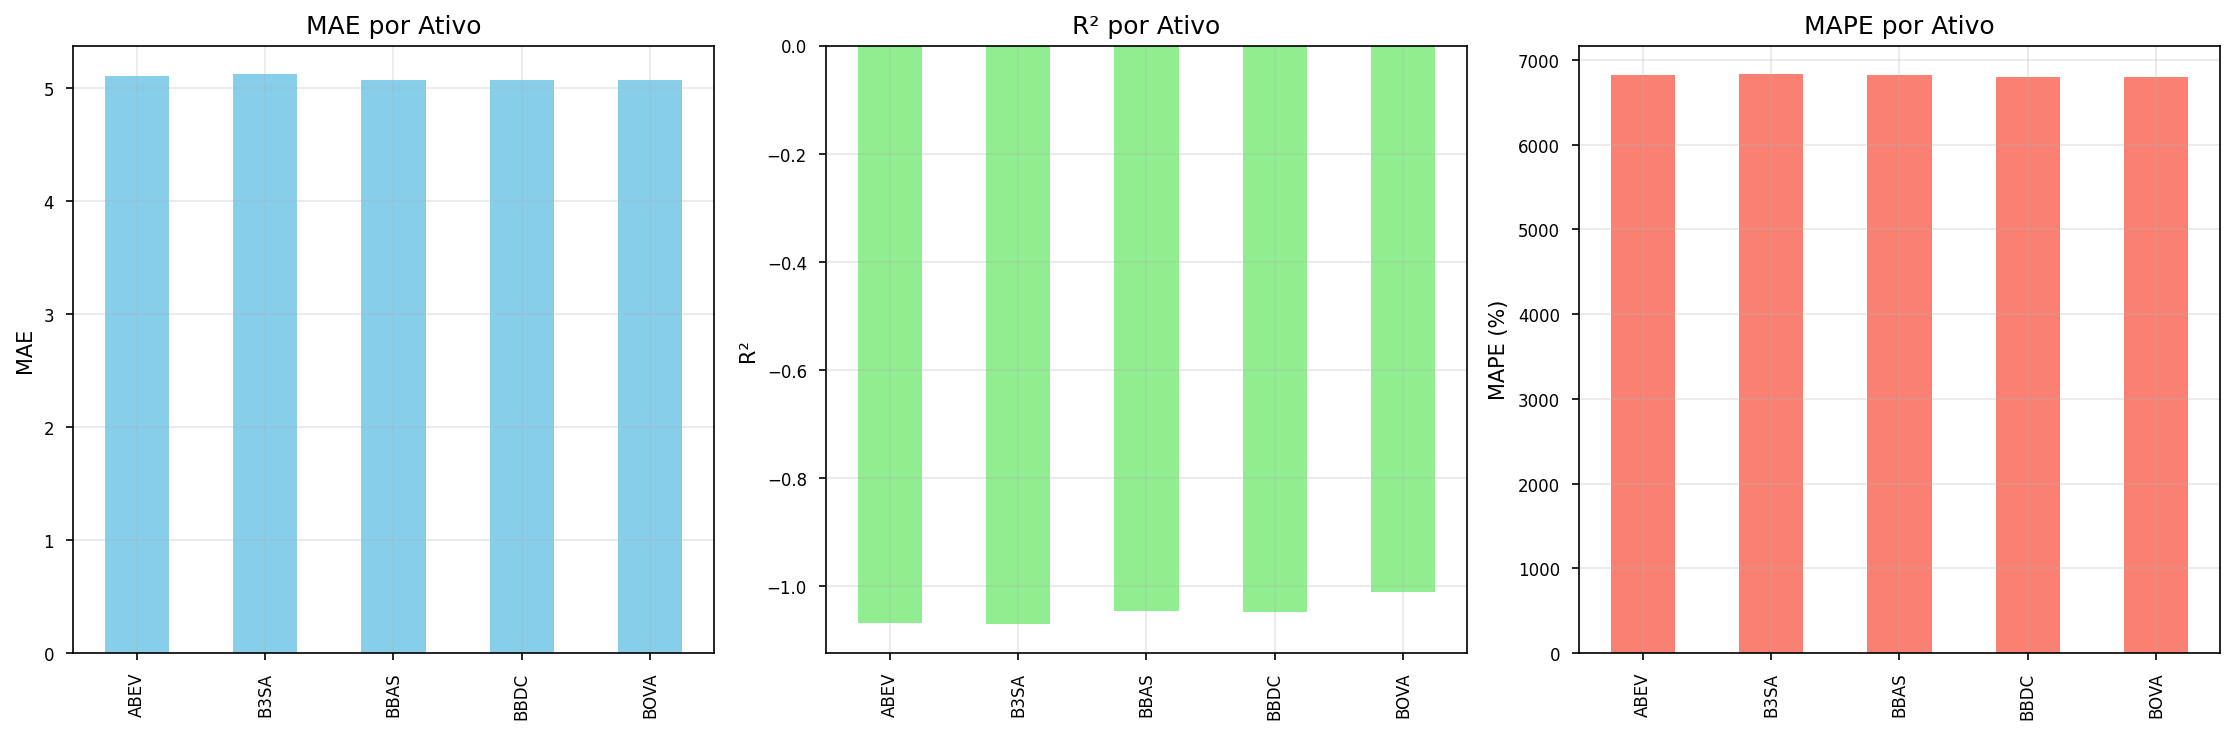

In [7]:
ativos_ft = [f.replace('best_', '').replace('.pt', '') for f in os.listdir(PATHS['model_save_dir']) 
             if f.startswith('best_') and f.endswith('.pt')]

print(f"Modelos fine-tuned encontrados: {len(ativos_ft)}")
print(f"Ativos: {ativos_ft}")

results_ft = {}
for ativo in ativos_ft[:5]:  # Avalia primeiros 5 para exemplo
    ft_path = os.path.join(PATHS['model_save_dir'], f'best_{ativo}.pt')
    if os.path.exists(ft_path):
        try:
            model_ft = load_adaptive_model(DeepHestonHybrid, MODEL_CONFIG, data_stats, ft_path, device)
            loader_2024 = DataLoader(ds_2024, batch_size=512, shuffle=False)
            results_ft[ativo] = avaliar_modelo(model_ft, loader_2024, data_stats, device, f"Fine-tuned {ativo}")
        except Exception as e:
            print(f"Erro ao avaliar {ativo}: {e}")

if results_ft:
    metrics_df = pd.DataFrame({
        ativo: res['metrics'] for ativo, res in results_ft.items()
    }).T
    
    print("\n" + "="*60)
    print("COMPARATIVO MODELOS FINE-TUNED")
    print("="*60)
    print(metrics_df.to_string())
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    metrics_df['MAE'].plot(kind='bar', ax=axes[0], color='skyblue')
    axes[0].set_title('MAE por Ativo')
    axes[0].set_ylabel('MAE')
    axes[0].grid(True, alpha=0.3)
    
    metrics_df['R2'].plot(kind='bar', ax=axes[1], color='lightgreen')
    axes[1].set_title('R² por Ativo')
    axes[1].set_ylabel('R²')
    axes[1].grid(True, alpha=0.3)
    
    metrics_df['MAPE'].plot(kind='bar', ax=axes[2], color='salmon')
    axes[2].set_title('MAPE por Ativo')
    axes[2].set_ylabel('MAPE (%)')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 7. Análise Comparativa Generalista vs Fine-Tuned


COMPARATIVO COMPLETO: GENERALISTA vs FINE-TUNED
     Modelo      MAE      RMSE        R2        MAPE  Erro_Medio  Std_Erro
Generalista 5.141789 11.586466 -1.089435 6844.687500   -1.154338 11.528821
    FT-ABEV 5.105587 11.529632 -1.068987 6822.706055   -1.133438 11.473784
    FT-B3SA 5.120406 11.532755 -1.070108 6829.547852   -1.161193 11.474147
    FT-BBAS 5.069113 11.467851 -1.046873 6820.566406   -1.052091 11.419490
    FT-BBDC 5.067226 11.468451 -1.047087 6801.137695   -1.099489 11.415627
    FT-BOVA 5.074130 11.365585 -1.010529 6798.499512   -1.231179 11.298703


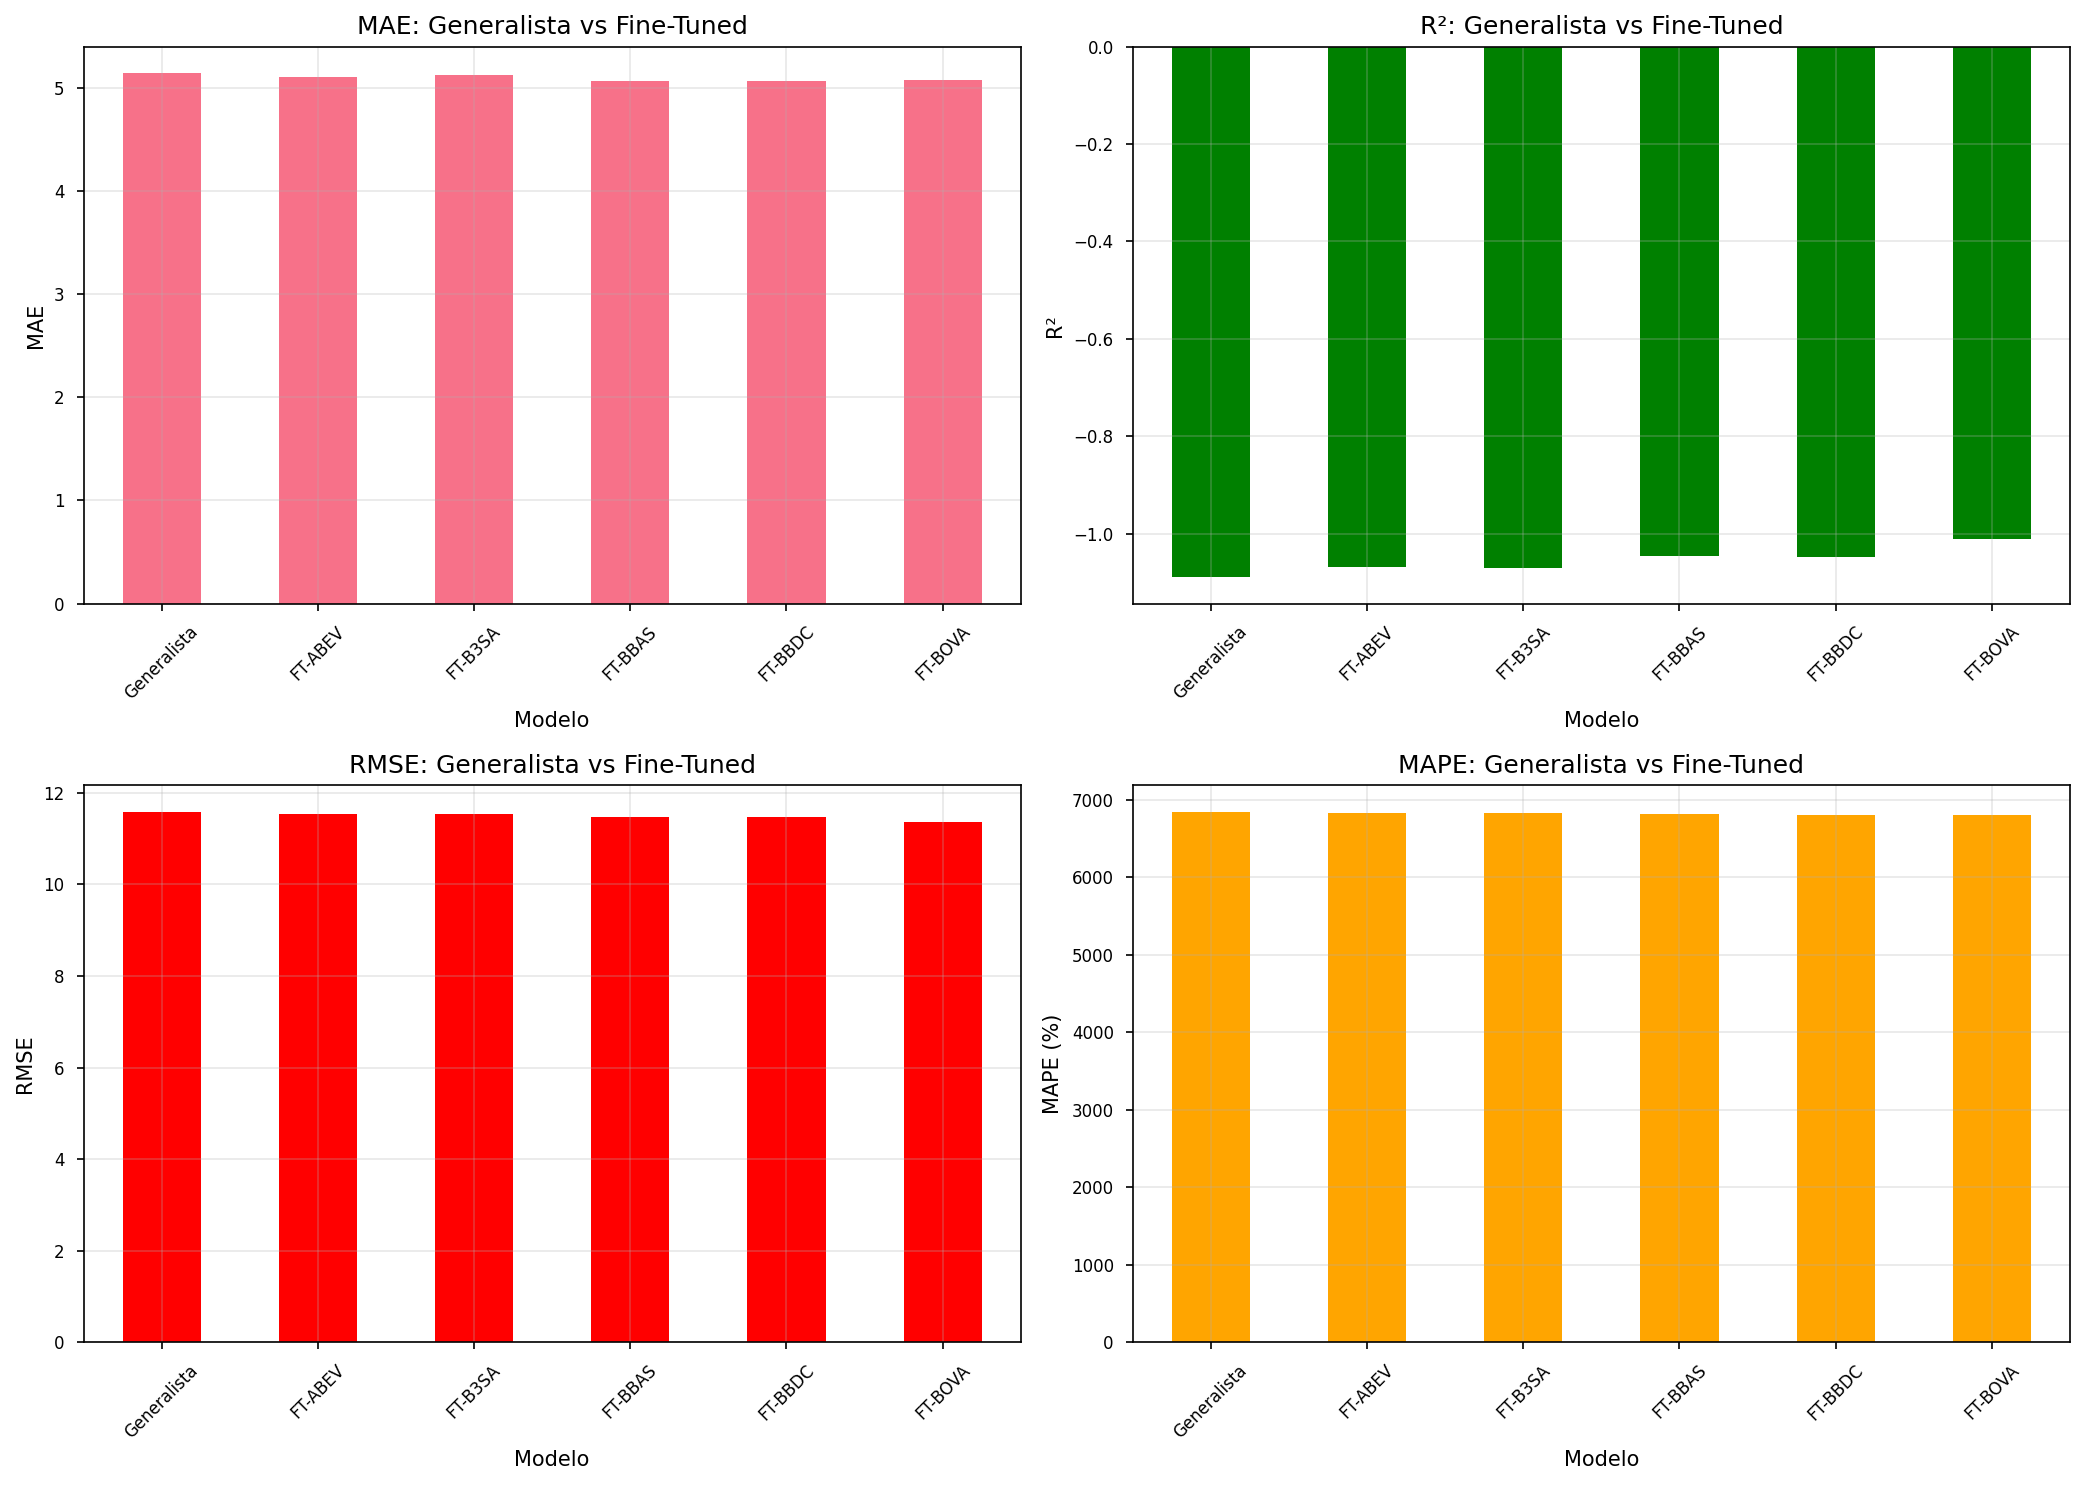

In [8]:
if 'results_gen' in locals() and results_ft:
    comp_data = []
    comp_data.append({'Modelo': 'Generalista', **results_gen['metrics']})
    for ativo, res in results_ft.items():
        comp_data.append({'Modelo': f'FT-{ativo}', **res['metrics']})
    
    comp_df = pd.DataFrame(comp_data)
    
    print("\n" + "="*80)
    print("COMPARATIVO COMPLETO: GENERALISTA vs FINE-TUNED")
    print("="*80)
    print(comp_df.to_string(index=False))
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    comp_df.plot(x='Modelo', y='MAE', kind='bar', ax=axes[0,0], legend=False)
    axes[0,0].set_title('MAE: Generalista vs Fine-Tuned')
    axes[0,0].set_ylabel('MAE')
    axes[0,0].tick_params(axis='x', rotation=45)
    axes[0,0].grid(True, alpha=0.3)
    
    comp_df.plot(x='Modelo', y='R2', kind='bar', ax=axes[0,1], legend=False, color='green')
    axes[0,1].set_title('R²: Generalista vs Fine-Tuned')
    axes[0,1].set_ylabel('R²')
    axes[0,1].tick_params(axis='x', rotation=45)
    axes[0,1].grid(True, alpha=0.3)
    
    comp_df.plot(x='Modelo', y='RMSE', kind='bar', ax=axes[1,0], legend=False, color='red')
    axes[1,0].set_title('RMSE: Generalista vs Fine-Tuned')
    axes[1,0].set_ylabel('RMSE')
    axes[1,0].tick_params(axis='x', rotation=45)
    axes[1,0].grid(True, alpha=0.3)
    
    comp_df.plot(x='Modelo', y='MAPE', kind='bar', ax=axes[1,1], legend=False, color='orange')
    axes[1,1].set_title('MAPE: Generalista vs Fine-Tuned')
    axes[1,1].set_ylabel('MAPE (%)')
    axes[1,1].tick_params(axis='x', rotation=45)
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 8. Análises Visuais Avançadas

### 8.1. Análise de Resíduos Detalhada

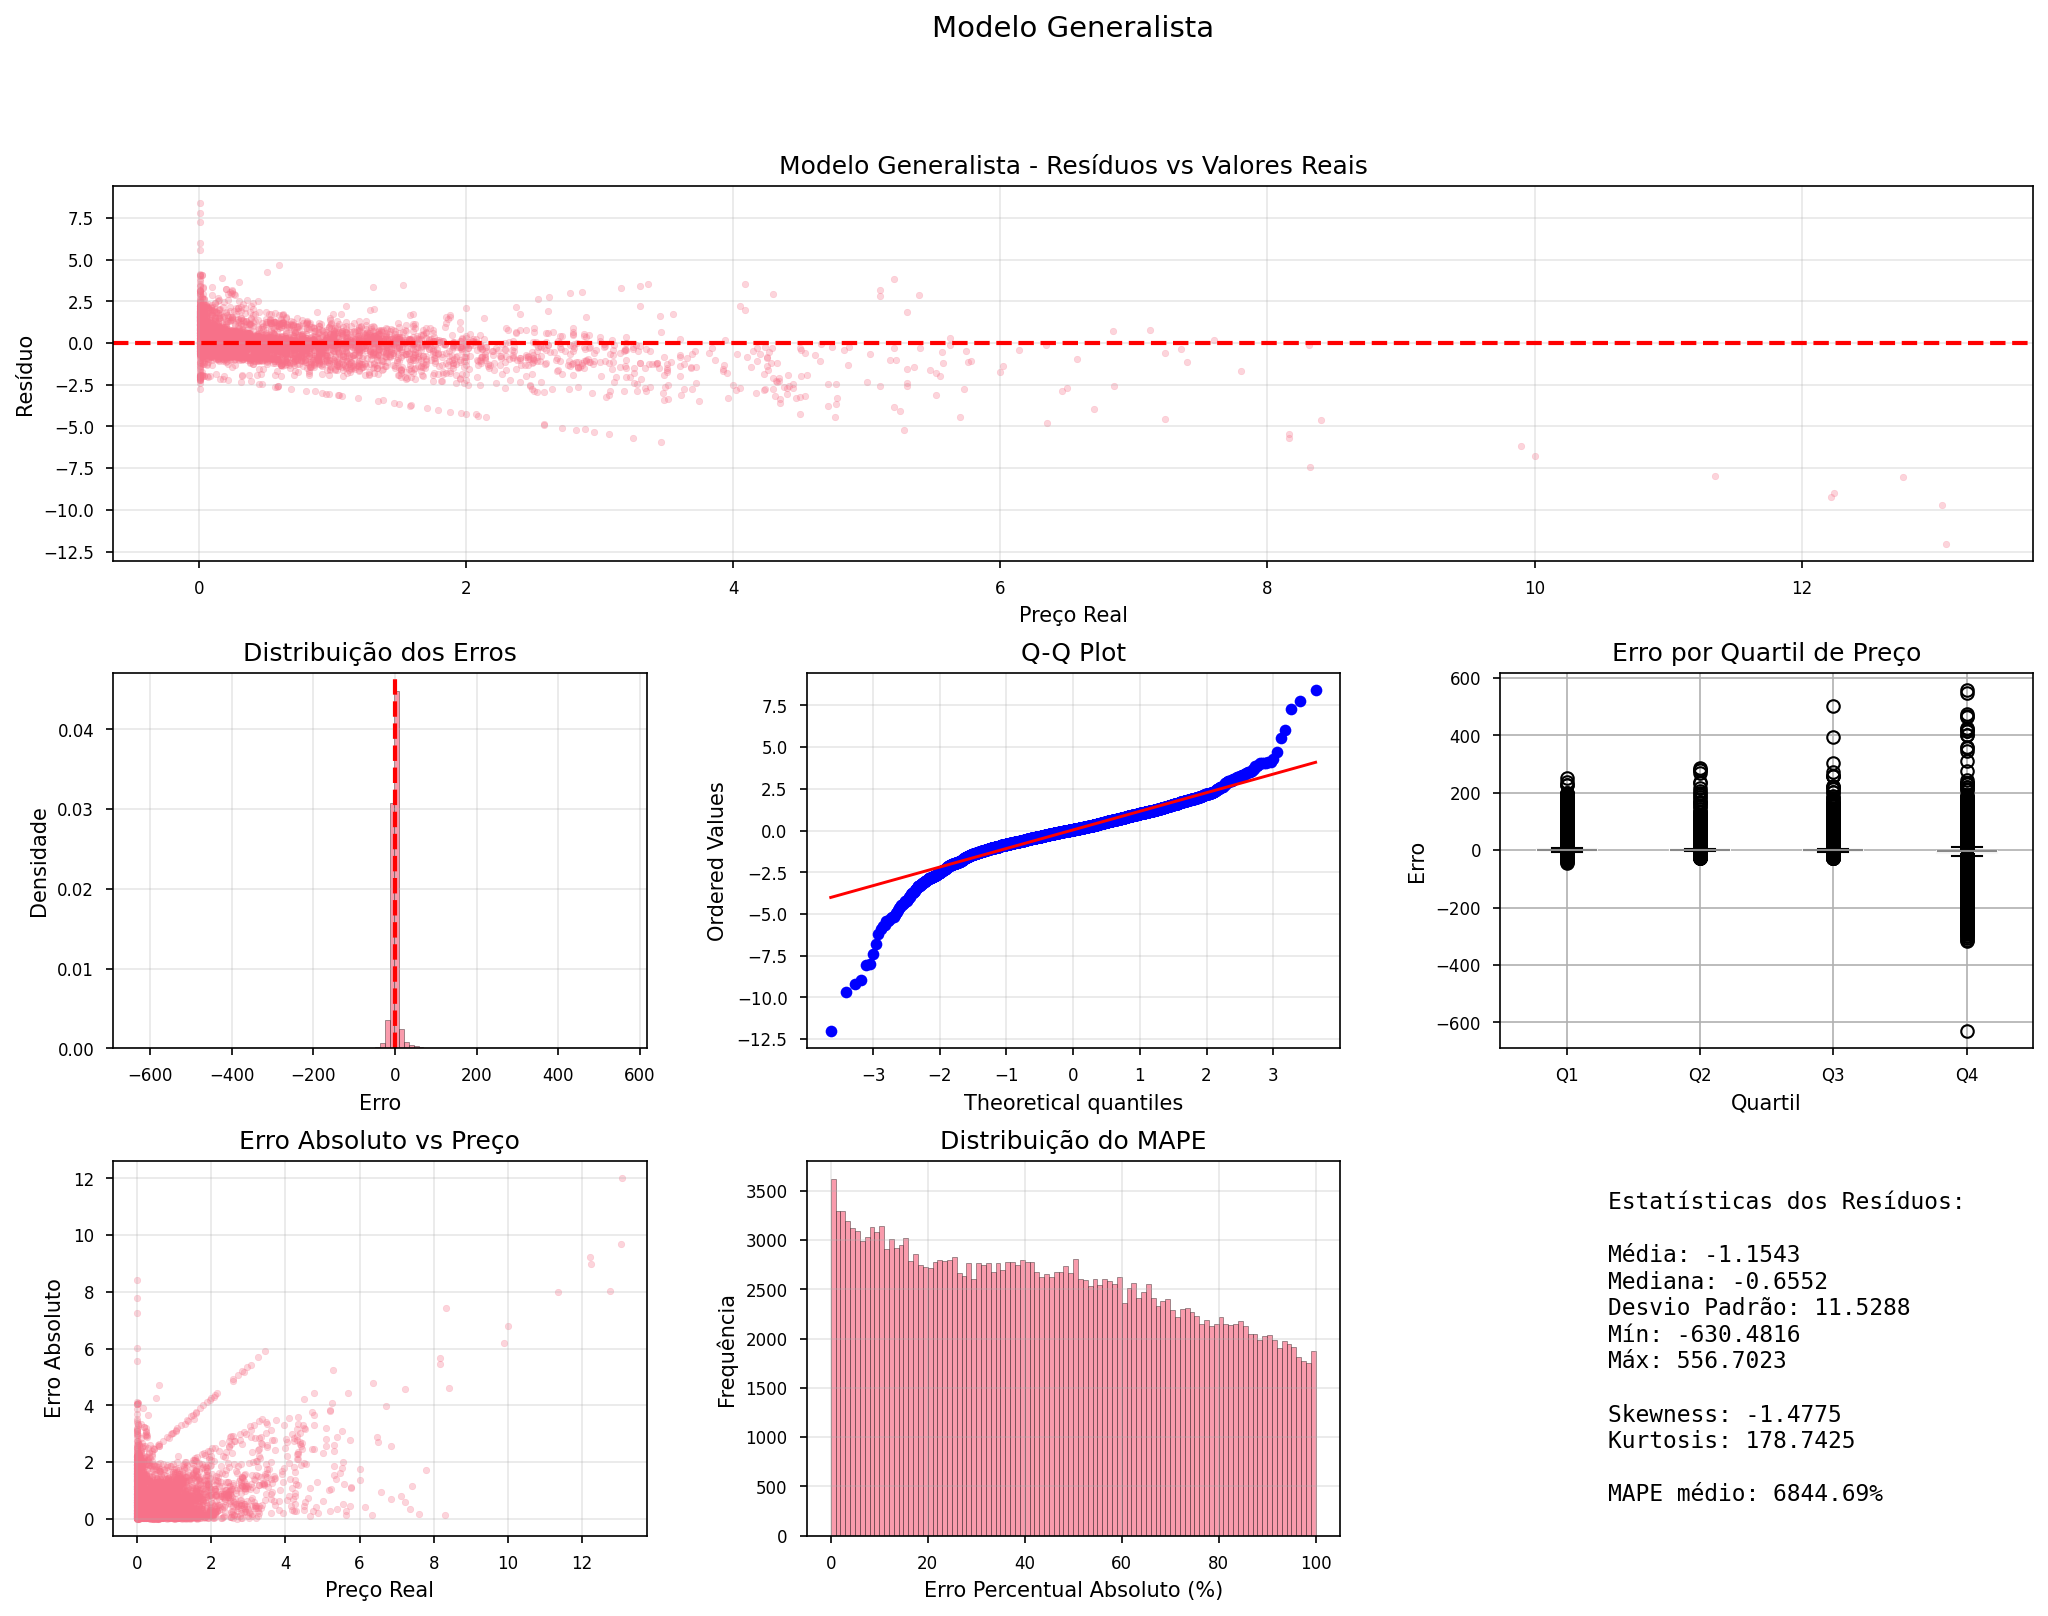

In [9]:
def plot_residual_analysis(results_dict, title="Análise de Resíduos"):
    """
    Painel completo de análise de resíduos
    """
    predictions = results_dict['predictions']
    targets = results_dict['targets']
    errors = predictions - targets
    
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # 1. Scatter de resíduos vs valores reais
    ax1 = fig.add_subplot(gs[0, :])
    ax1.scatter(targets[:5000], errors[:5000], alpha=0.3, s=10)
    ax1.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax1.set_xlabel('Preço Real')
    ax1.set_ylabel('Resíduo')
    ax1.set_title(f'{title} - Resíduos vs Valores Reais')
    ax1.grid(True, alpha=0.3)
    
    # 2. Histograma de erros
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.hist(errors, bins=100, alpha=0.7, edgecolor='black', density=True)
    ax2.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax2.set_xlabel('Erro')
    ax2.set_ylabel('Densidade')
    ax2.set_title('Distribuição dos Erros')
    ax2.grid(True, alpha=0.3)
    
    # 3. Q-Q Plot
    ax3 = fig.add_subplot(gs[1, 1])
    stats.probplot(errors[:5000], dist="norm", plot=ax3)
    ax3.set_title('Q-Q Plot')
    ax3.grid(True, alpha=0.3)
    
    # 4. Boxplot por quartis de preço
    ax4 = fig.add_subplot(gs[1, 2])
    quartiles = pd.qcut(targets, q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
    df_box = pd.DataFrame({'Erro': errors, 'Quartil': quartiles})
    df_box.boxplot(column='Erro', by='Quartil', ax=ax4)
    ax4.set_title('Erro por Quartil de Preço')
    ax4.set_xlabel('Quartil')
    ax4.set_ylabel('Erro')
    plt.sca(ax4)
    plt.xticks(rotation=0)
    
    # 5. Erro absoluto vs preço
    ax5 = fig.add_subplot(gs[2, 0])
    ax5.scatter(targets[:5000], np.abs(errors[:5000]), alpha=0.3, s=10)
    ax5.set_xlabel('Preço Real')
    ax5.set_ylabel('Erro Absoluto')
    ax5.set_title('Erro Absoluto vs Preço')
    ax5.grid(True, alpha=0.3)
    
    # 6. Erro percentual
    ax6 = fig.add_subplot(gs[2, 1])
    pct_error = 100 * np.abs(errors) / (np.abs(targets) + 1e-8)
    ax6.hist(pct_error[pct_error < 100], bins=100, alpha=0.7, edgecolor='black')
    ax6.set_xlabel('Erro Percentual Absoluto (%)')
    ax6.set_ylabel('Frequência')
    ax6.set_title('Distribuição do MAPE')
    ax6.grid(True, alpha=0.3)
    
    # 7. Estatísticas
    ax7 = fig.add_subplot(gs[2, 2])
    ax7.axis('off')
    stats_text = f"""
    Estatísticas dos Resíduos:
    
    Média: {np.mean(errors):.4f}
    Mediana: {np.median(errors):.4f}
    Desvio Padrão: {np.std(errors):.4f}
    Mín: {np.min(errors):.4f}
    Máx: {np.max(errors):.4f}
    
    Skewness: {stats.skew(errors):.4f}
    Kurtosis: {stats.kurtosis(errors):.4f}
    
    MAPE médio: {np.mean(pct_error):.2f}%
    """
    ax7.text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
             verticalalignment='center')
    
    plt.suptitle(title, fontsize=14, y=0.995)
    plt.show()

if results_gen:
    plot_residual_analysis(results_gen, "Modelo Generalista")

### 8.2. Séries Temporais - Preço Real vs Predito

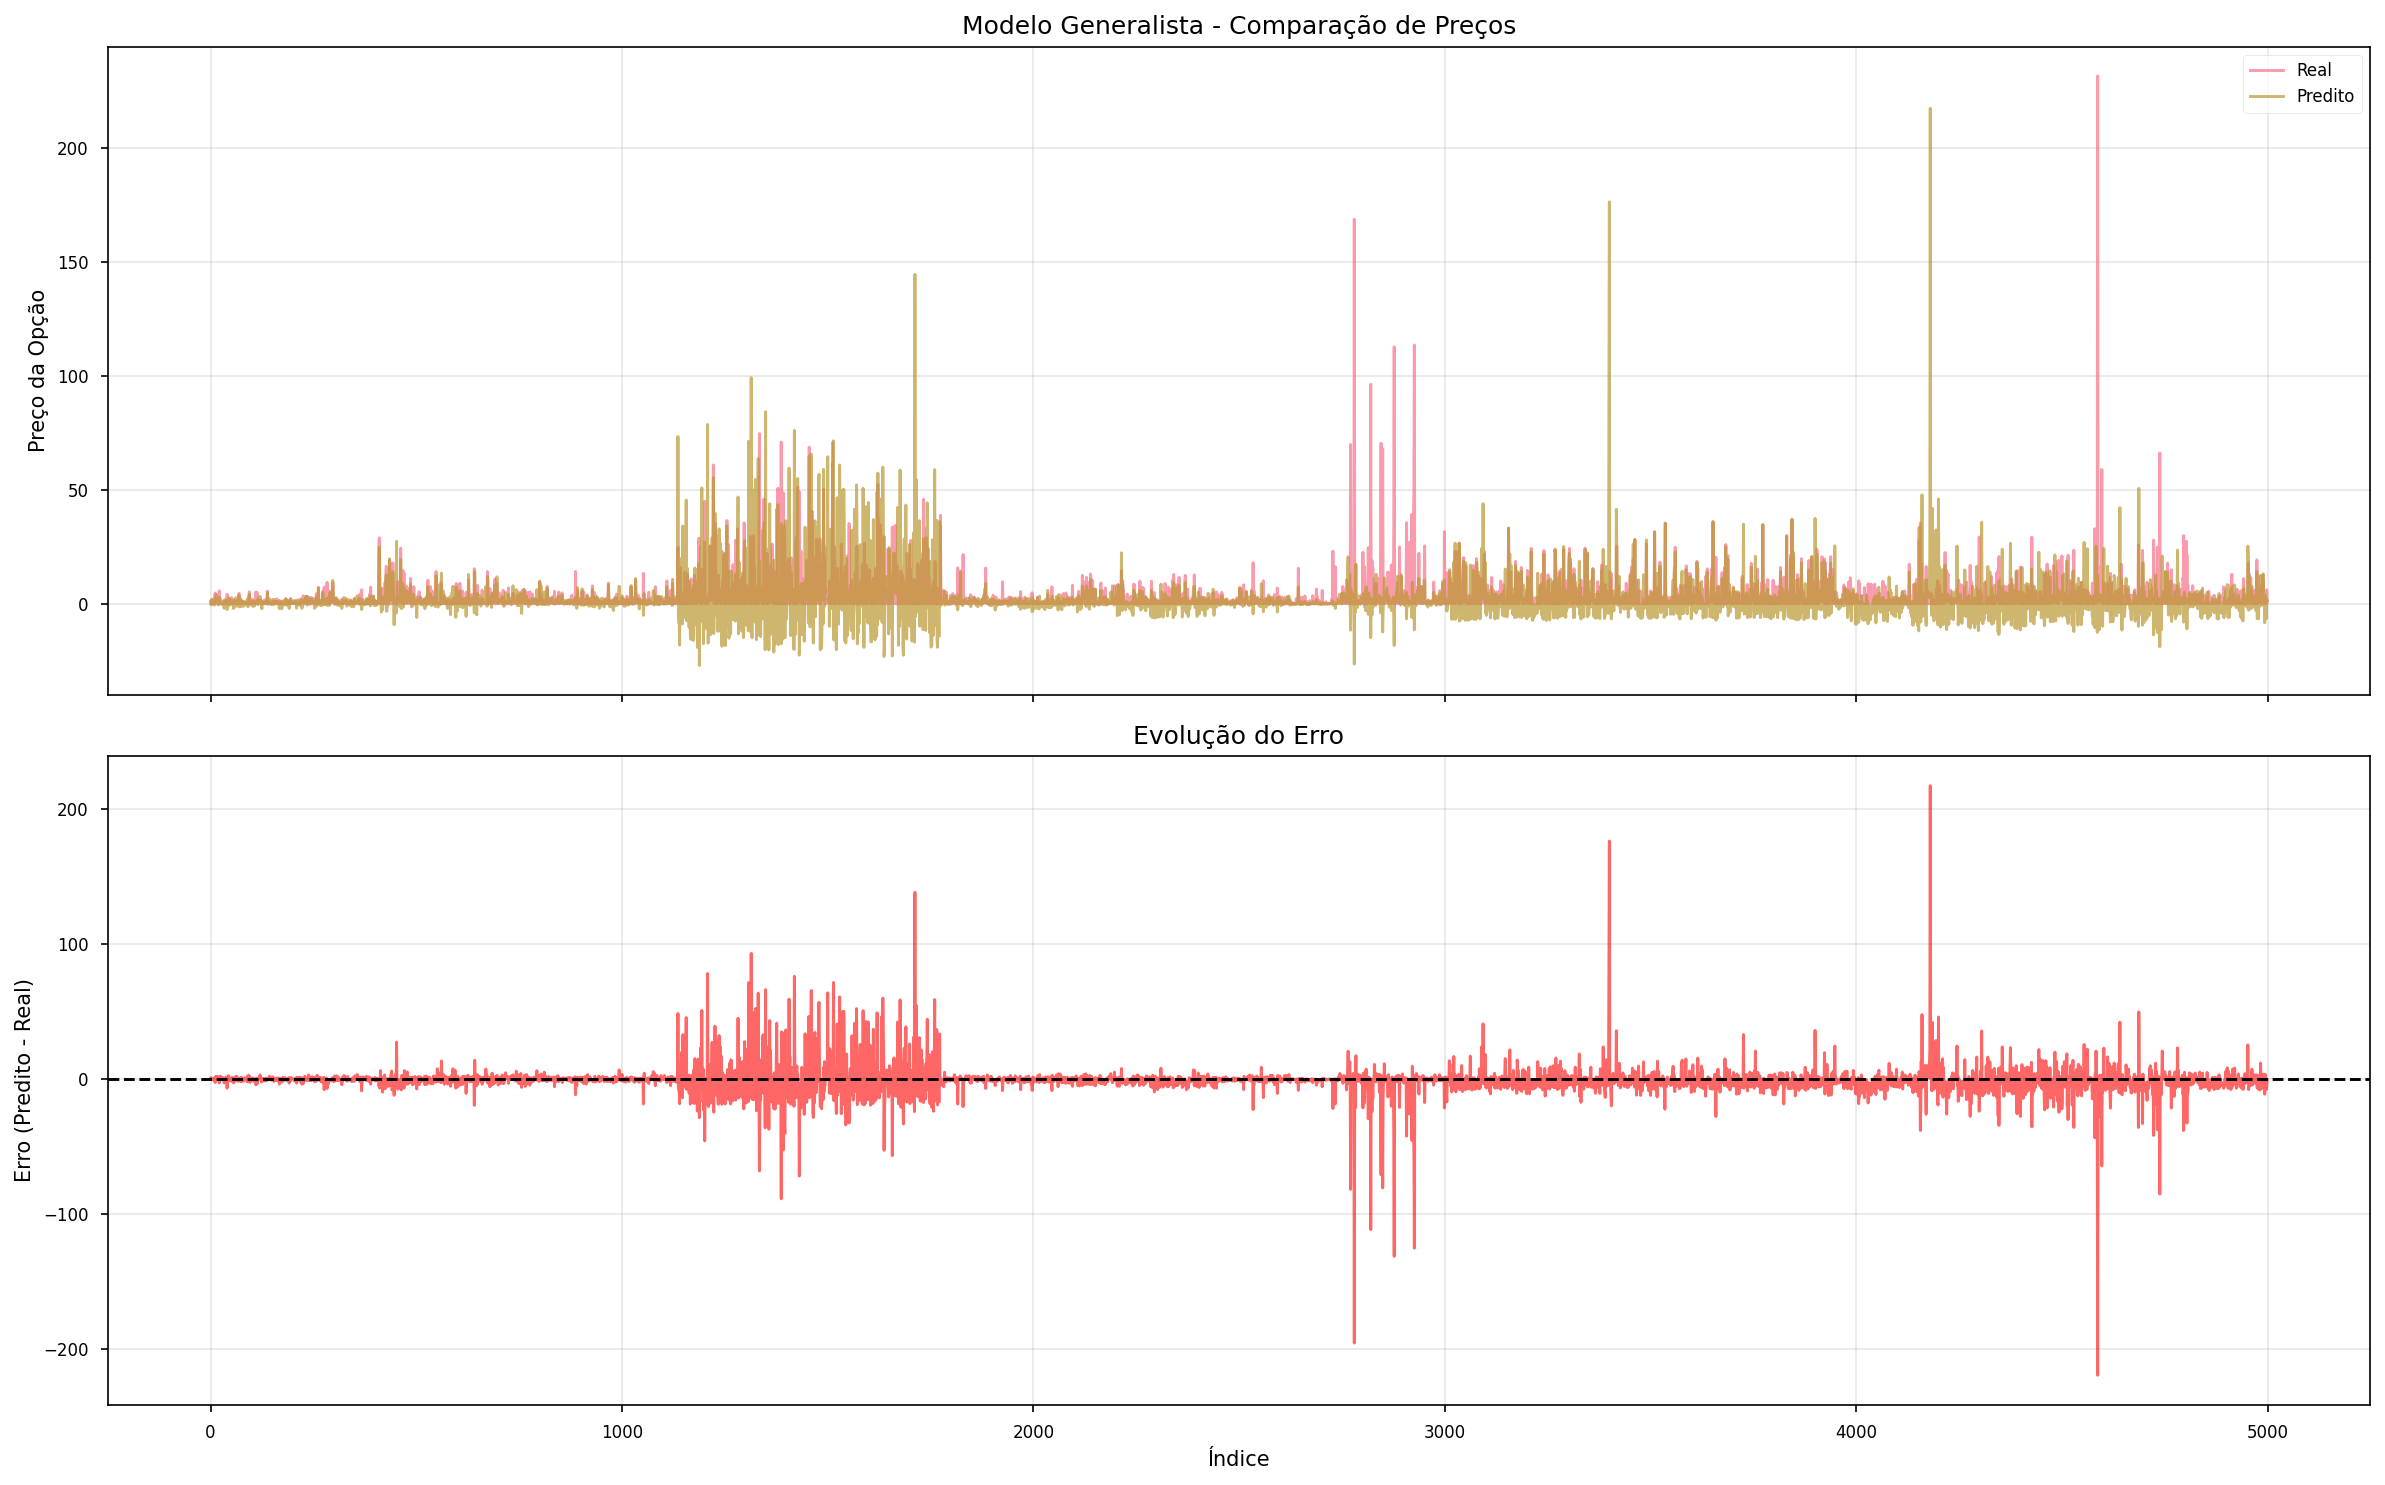

In [10]:
def plot_price_time_series(results_dict, title="Série Temporal de Preços", sample_size=None):
    """
    Plota série temporal de preços reais vs preditos
    """
    predictions = results_dict['predictions']
    targets = results_dict['targets']
    
    # Converter timestamps se disponível
    if 'timestamps' in results_dict:
        timestamps = pd.to_datetime(results_dict['timestamps'], unit='s')
        df = pd.DataFrame({
            'Date': timestamps,
            'Real': targets,
            'Predito': predictions,
            'Erro': predictions - targets
        })
        df = df.sort_values('Date')
    else:
        df = pd.DataFrame({
            'Real': targets,
            'Predito': predictions,
            'Erro': predictions - targets
        })
    
    if sample_size:
        df = df.sample(n=min(sample_size, len(df)))
        if 'Date' in df.columns:
            df = df.sort_values('Date')
        else:
            df = df.sort_index()
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
    
    # Subplot 1: Preços
    if 'Date' in df.columns:
        axes[0].plot(df['Date'], df['Real'], label='Real', alpha=0.7, linewidth=1)
        axes[0].plot(df['Date'], df['Predito'], label='Predito', alpha=0.7, linewidth=1)
    else:
        axes[0].plot(df['Real'].values, label='Real', alpha=0.7)
        axes[0].plot(df['Predito'].values, label='Predito', alpha=0.7)
    
    axes[0].set_ylabel('Preço da Opção')
    axes[0].set_title(f'{title} - Comparação de Preços')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Subplot 2: Erro ao longo do tempo
    if 'Date' in df.columns:
        axes[1].plot(df['Date'], df['Erro'], color='red', alpha=0.6, linewidth=1)
        axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
    else:
        axes[1].plot(df['Erro'].values, color='red', alpha=0.6)
        axes[1].axhline(y=0, color='black', linestyle='--')
    
    axes[1].set_ylabel('Erro (Predito - Real)')
    axes[1].set_title('Evolução do Erro')
    axes[1].set_xlabel('Data' if 'Date' in df.columns else 'Índice')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return df

# Aplicar ao modelo generalista
if results_gen:
    df_gen = plot_price_time_series(results_gen, "Modelo Generalista", sample_size=5000)

### 8.3. Análise por Moneyness e Maturidade

In [11]:
def plot_cross_sections(results_dict, title="Cross-Sections"):
    """
    Analisa preço vs moneyness e maturidade
    """
    if 'moneyness' not in results_dict or 'maturity' not in results_dict:
        print("Moneyness ou maturidade não disponíveis")
        return
    
    predictions = results_dict['predictions']
    targets = results_dict['targets']
    moneyness = results_dict['moneyness']  # S/K
    maturity = results_dict['maturity']    # T em anos
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Preço vs Moneyness (bins de maturidade)
    mat_bins = pd.qcut(maturity, q=3, labels=['Curto', 'Médio', 'Longo'])
    
    for mat_label in ['Curto', 'Médio', 'Longo']:
        mask = (mat_bins == mat_label)
        axes[0, 0].scatter(moneyness[mask], targets[mask], 
                          alpha=0.3, s=10, label=f'{mat_label} - Real')
        axes[0, 0].scatter(moneyness[mask], predictions[mask], 
                          alpha=0.3, s=10, marker='x', label=f'{mat_label} - Pred')
    
    axes[0, 0].set_xlabel('Moneyness (S/K)')
    axes[0, 0].set_ylabel('Preço')
    axes[0, 0].set_title('Preço vs Moneyness por Maturidade')
    axes[0, 0].legend(fontsize=8)
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Preço vs Maturidade (bins de moneyness)
    money_bins = pd.qcut(moneyness, q=3, labels=['OTM', 'ATM', 'ITM'])
    
    for money_label in ['OTM', 'ATM', 'ITM']:
        mask = (money_bins == money_label)
        axes[0, 1].scatter(maturity[mask], targets[mask], 
                          alpha=0.3, s=10, label=f'{money_label} - Real')
        axes[0, 1].scatter(maturity[mask], predictions[mask], 
                          alpha=0.3, s=10, marker='x', label=f'{money_label} - Pred')
    
    axes[0, 1].set_xlabel('Maturidade (anos)')
    axes[0, 1].set_ylabel('Preço')
    axes[0, 1].set_title('Preço vs Maturidade por Moneyness')
    axes[0, 1].legend(fontsize=8)
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Erro vs Moneyness
    errors = predictions - targets
    axes[1, 0].scatter(moneyness[:5000], errors[:5000], alpha=0.3, s=10)
    axes[1, 0].axhline(y=0, color='red', linestyle='--')
    axes[1, 0].set_xlabel('Moneyness (S/K)')
    axes[1, 0].set_ylabel('Erro')
    axes[1, 0].set_title('Erro vs Moneyness')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Erro vs Maturidade
    axes[1, 1].scatter(maturity[:5000], errors[:5000], alpha=0.3, s=10)
    axes[1, 1].axhline(y=0, color='red', linestyle='--')
    axes[1, 1].set_xlabel('Maturidade (anos)')
    axes[1, 1].set_ylabel('Erro')
    axes[1, 1].set_title('Erro vs Maturidade')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# Aplicar se dados disponíveis
if results_gen and 'moneyness' in results_gen:
    plot_cross_sections(results_gen, "Modelo Generalista")

### 8.4. Heatmap de Erros (2D)

In [12]:
def plot_error_heatmap(results_dict, title="Heatmap de Erros"):
    """
    Cria heatmap 2D de erro absoluto por moneyness x maturidade
    """
    if 'moneyness' not in results_dict or 'maturity' not in results_dict:
        print("Moneyness ou maturidade não disponíveis")
        return
    
    predictions = results_dict['predictions']
    targets = results_dict['targets']
    moneyness = results_dict['moneyness']
    maturity = results_dict['maturity']
    
    abs_errors = np.abs(predictions - targets)
    
    # Criar bins
    money_bins = pd.cut(moneyness, bins=20)
    mat_bins = pd.cut(maturity, bins=15)
    
    # Calcular erro médio por bin
    df = pd.DataFrame({
        'moneyness': money_bins,
        'maturity': mat_bins,
        'abs_error': abs_errors
    })
    
    pivot = df.pivot_table(values='abs_error', 
                           index='maturity', 
                           columns='moneyness', 
                           aggfunc='mean')
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    sns.heatmap(pivot, annot=False, fmt=".3f", cmap='YlOrRd', 
                cbar_kws={'label': 'Erro Absoluto Médio'}, ax=ax)
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Moneyness (S/K)')
    ax.set_ylabel('Maturidade (anos)')
    
    # Melhorar labels
    ax.set_xticks(np.arange(len(pivot.columns)) + 0.5)
    ax.set_xticklabels([f'{x.mid:.2f}' for x in pivot.columns], rotation=45)
    
    ax.set_yticks(np.arange(len(pivot.index)) + 0.5)
    ax.set_yticklabels([f'{y.mid:.2f}' for y in pivot.index], rotation=0)

    
    plt.tight_layout()
    plt.show()

if results_gen and 'moneyness' in results_gen:
    plot_error_heatmap(results_gen, "Heatmap de Erros - Generalista")

### 8.5. Superfície 3D de Preços

In [13]:
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
from scipy.interpolate import griddata

def plot_3d_price_surface(results_dict, title="Superfície de Preços", plot_real=True):
    if 'moneyness' not in results_dict or 'maturity' not in results_dict:
        print("Moneyness ou maturidade não disponíveis nos resultados.")
        return
    
    # 1. Extração e Limpeza dos Dados
    moneyness = np.array(results_dict['moneyness'])
    maturity = np.array(results_dict['maturity'])
    predictions = np.array(results_dict['predictions'])
    targets = np.array(results_dict['targets'])
    
    # Filtrar outliers extremos de Moneyness para melhor visualização (foco em 0.7 a 1.3 costuma ser ideal)
    mask = (moneyness >= 0.7) & (moneyness <= 1.3)
    
    mon_clean = moneyness[mask]
    mat_clean = maturity[mask]
    pred_clean = predictions[mask]
    real_clean = targets[mask]
    
    # 2. Criação da Malha (Grid) para Interpolação
    # Cria 100x100 pontos entre os valores mínimos e máximos
    grid_x, grid_y = np.mgrid[
        mon_clean.min():mon_clean.max():100j, 
        mat_clean.min():mat_clean.max():100j
    ]
    
    # 3. Interpolação (Cubic gera curvas suaves, Linear é mais seguro se tiver poucos dados)
    # Z_pred é a superfície de preços previstos
    Z_pred = griddata((mon_clean, mat_clean), pred_clean, (grid_x, grid_y), method='cubic')
    
    fig = plt.figure(figsize=(20, 8))
    
    if plot_real:
        # Interpolação dos dados reais
        Z_real = griddata((mon_clean, mat_clean), real_clean, (grid_x, grid_y), method='cubic')
        
        # --- Plot 1: Real ---
        ax1 = fig.add_subplot(121, projection='3d')
        surf1 = ax1.plot_surface(grid_x, grid_y, Z_real, cmap=cm.viridis, 
                               edgecolor='none', alpha=0.9, antialiased=True)
        ax1.set_xlabel('Moneyness (S/K)')
        ax1.set_ylabel('Maturidade (Anos)')
        ax1.set_zlabel('Preço Real')
        ax1.set_title('Superfície Real (Interpolada)')
        ax1.view_init(elev=30, azim=-60) # Ajuste o ângulo de visão aqui
        fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)

        # --- Plot 2: Predito ---
        ax2 = fig.add_subplot(122, projection='3d')
        surf2 = ax2.plot_surface(grid_x, grid_y, Z_pred, cmap=cm.plasma, 
                               edgecolor='none', alpha=0.9, antialiased=True)
        ax2.set_xlabel('Moneyness (S/K)')
        ax2.set_ylabel('Maturidade (Anos)')
        ax2.set_zlabel('Preço Previsto')
        ax2.set_title('Superfície Predita (PINN)')
        ax2.view_init(elev=30, azim=-60)
        fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)
        
    else:
        # Plot único apenas das previsões
        ax = fig.add_subplot(111, projection='3d')
        surf = ax.plot_surface(grid_x, grid_y, Z_pred, cmap=cm.viridis, 
                             edgecolor='none', antialiased=True)
        ax.set_xlabel('Moneyness (S/K)')
        ax.set_ylabel('Maturidade (Anos)')
        ax.set_zlabel('Preço')
        ax.set_title(f'{title} - Predito')
        fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

if results_gen and 'moneyness' in results_gen:
    plot_3d_price_surface(results_gen, "Superfície 3D - Generalista", plot_real=True)

### 8.6. Análise de Volatilidade Latente


In [14]:
def plot_latent_volatility(results_dict, title="Volatilidade Latente"):
    """
    Plota evolução da volatilidade latente estimada pelo modelo
    """
    if 'volatilities' not in results_dict or results_dict['volatilities'] is None:
        print("Volatilidades latentes não disponíveis")
        return
    
    vols = results_dict['volatilities']
    
    if 'timestamps' in results_dict:
        timestamps = pd.to_datetime(results_dict['timestamps'], unit='s')
        df = pd.DataFrame({'Date': timestamps, 'Vol': vols})
        df = df.sort_values('Date')
        
        # Agrupar por dia
        df_daily = df.groupby(df['Date'].dt.date).agg({'Vol': ['mean', 'std', 'min', 'max']})
        df_daily.columns = ['mean', 'std', 'min', 'max']
        
        fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
        
        # Subplot 1: Média diária com intervalo
        axes[0].plot(df_daily.index, df_daily['mean'], label='Média', linewidth=2)
        axes[0].fill_between(df_daily.index, 
                            df_daily['mean'] - df_daily['std'],
                            df_daily['mean'] + df_daily['std'],
                            alpha=0.3, label='±1 DP')
        axes[0].set_ylabel('Volatilidade')
        axes[0].set_title(f'{title} - Evolução Temporal')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Subplot 2: Range
        axes[1].plot(df_daily.index, df_daily['max'], label='Máx', alpha=0.7)
        axes[1].plot(df_daily.index, df_daily['min'], label='Mín', alpha=0.7)
        axes[1].fill_between(df_daily.index, df_daily['min'], df_daily['max'], 
                            alpha=0.2)
        axes[1].set_ylabel('Volatilidade')
        axes[1].set_xlabel('Data')
        axes[1].set_title('Range de Volatilidade')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    else:
        # Histograma simples
        plt.figure(figsize=(12, 6))
        plt.hist(vols, bins=100, alpha=0.7, edgecolor='black')
        plt.xlabel('Volatilidade Latente')
        plt.ylabel('Frequência')
        plt.title(f'{title} - Distribuição')
        plt.grid(True, alpha=0.3)
        plt.show()

if results_gen:
    plot_latent_volatility(results_gen, "Volatilidade Latente - Generalista")

Volatilidades latentes não disponíveis


### 8.7. Comparação Generalista vs Fine-Tuned

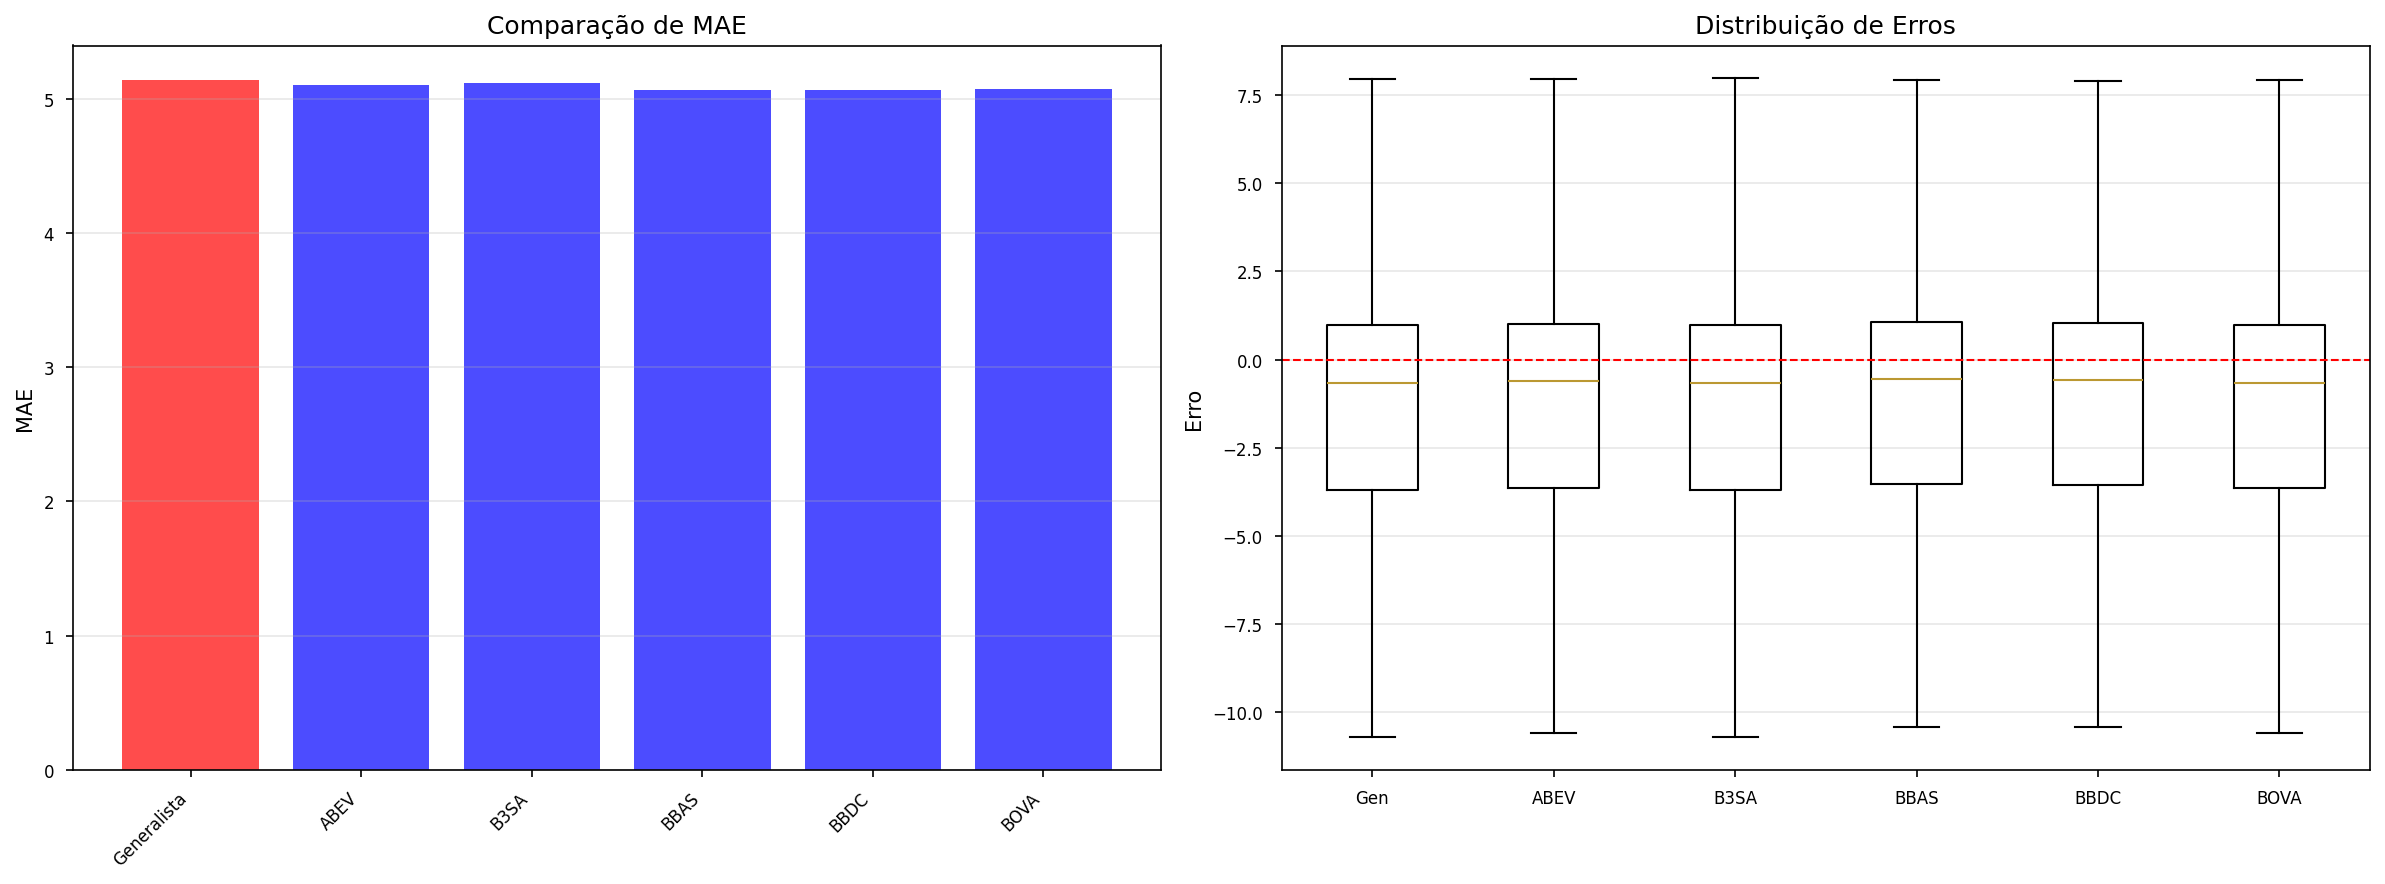

In [15]:
def compare_models_visual(results_gen, results_ft_dict, metric='MAE'):
    """
    Compara visualmente generalista vs modelos fine-tuned
    """
    if not results_ft_dict:
        print("Nenhum modelo fine-tuned disponível")
        return
    
    # Coletar métricas
    models = ['Generalista'] + list(results_ft_dict.keys())
    metrics_values = [results_gen['metrics'][metric]]
    
    for ativo in results_ft_dict:
        metrics_values.append(results_ft_dict[ativo]['metrics'][metric])
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Gráfico de barras
    colors = ['red'] + ['blue'] * (len(models) - 1)
    axes[0].bar(range(len(models)), metrics_values, color=colors, alpha=0.7)
    axes[0].set_xticks(range(len(models)))
    axes[0].set_xticklabels(models, rotation=45, ha='right')
    axes[0].set_ylabel(metric)
    axes[0].set_title(f'Comparação de {metric}')
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Boxplot de erros
    all_errors = []
    labels = []
    
    gen_errors = results_gen['predictions'] - results_gen['targets']
    all_errors.append(gen_errors)
    labels.append('Gen')
    
    for ativo in list(results_ft_dict.keys())[:5]:  # Primeiros 5
        ft_errors = results_ft_dict[ativo]['predictions'] - results_ft_dict[ativo]['targets']
        all_errors.append(ft_errors)
        labels.append(ativo[:4])  # Abreviar
    
    axes[1].boxplot(all_errors, labels=labels, showfliers=False)
    axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
    axes[1].set_ylabel('Erro')
    axes[1].set_title('Distribuição de Erros')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

if results_gen and results_ft:
    compare_models_visual(results_gen, results_ft, metric='MAE')

## 8.8. Rolling Window Performance

In [16]:
def plot_rolling_metrics(results_dict, window=20, title="Performance Rolling Window"):
    """
    Plota métricas em janela móvel ao longo do tempo
    """
    if 'timestamps' not in results_dict:
        print("Timestamps não disponíveis")
        return
    
    predictions = results_dict['predictions']
    targets = results_dict['targets']
    timestamps = pd.to_datetime(results_dict['timestamps'], unit='s')
    
    df = pd.DataFrame({
        'Date': timestamps,
        'Pred': predictions,
        'Real': targets,
        'AE': np.abs(predictions - targets),
        'SE': (predictions - targets)**2
    })
    df = df.sort_values('Date')
    
    # Agrupar por dia
    df_daily = df.groupby(df['Date'].dt.date).agg({
        'AE': 'mean',
        'SE': 'mean'
    })
    
    df_daily['MAE_roll'] = df_daily['AE'].rolling(window=window, min_periods=1).mean()
    df_daily['RMSE_roll'] = np.sqrt(df_daily['SE'].rolling(window=window, min_periods=1).mean())
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
    
    # MAE Rolling
    axes[0].plot(df_daily.index, df_daily['MAE_roll'], linewidth=2, label=f'MAE (janela={window})')
    axes[0].fill_between(df_daily.index, 0, df_daily['MAE_roll'], alpha=0.3)
    axes[0].set_ylabel('MAE')
    axes[0].set_title(f'{title} - MAE em Janela Móvel')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # RMSE Rolling
    axes[1].plot(df_daily.index, df_daily['RMSE_roll'], linewidth=2, color='orange', label=f'RMSE (janela={window})')
    axes[1].fill_between(df_daily.index, 0, df_daily['RMSE_roll'], alpha=0.3, color='orange')
    axes[1].set_ylabel('RMSE')
    axes[1].set_xlabel('Data')
    axes[1].set_title(f'{title} - RMSE em Janela Móvel')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if results_gen and 'timestamps' in results_gen:
    plot_rolling_metrics(results_gen, window=30, title="Generalista")

### 8.9 Séries Históricas (Comparação de Tendência)

In [17]:
from torch.utils.data import Subset

# --- CORREÇÃO DO ERRO: Criar loaders_ft ---
def create_asset_loaders(dataset, data_stats, batch_size=512):
    """Separa o dataset completo em loaders individuais por ativo"""
    if dataset is None: return {}
    
    asset_map = data_stats['asset_map']
    loaders = {}
    
    # O tensor de asset_ids é o último (índice 5) no TensorDataset
    all_asset_ids = dataset.tensors[5].cpu().numpy().flatten()
    
    for asset_name, asset_id in asset_map.items():
        # Encontrar índices onde o asset_id corresponde ao ativo atual
        indices = np.where(all_asset_ids == asset_id)[0]
        
        if len(indices) > 0:
            # Criar subset apenas com dados desse ativo
            subset = Subset(dataset, indices)
            loaders[asset_name] = DataLoader(subset, batch_size=batch_size, shuffle=False)
    
    print(f"Loaders criados para {len(loaders)} ativos.")
    return loaders

# Criar loaders_ft usando o dataset de validação (ds_2024)
if 'ds_2024' in locals() and 'data_stats' in locals():
    loaders_ft = create_asset_loaders(ds_2024, data_stats)
else:
    print("AVISO: ds_2024 ou data_stats não encontrados. Execute as células de carregamento de dados primeiro.")
    loaders_ft = {}

Loaders criados para 14 ativos.


In [18]:
# --- 8.9 Séries Históricas (Tracking de Tendência) ---
def plot_historical_series(asset_name, results_real, results_gen, results_ft=None):
    """
    Plota a série temporal de preços médios diários para opções ATM (At-The-Money).
    Filtra opções com moneyness entre 0.95 e 1.05 para limpar o ruído.
    """
    # Criar DataFrame para facilitar manipulação temporal
    df = pd.DataFrame({
        'Date': pd.to_datetime(results_real['timestamps'], unit='s'), # Ajuste se necessário para o formato do seu timestamp
        'Moneyness': results_real['moneyness'],
        'Real': results_real['targets'],
        'Gen_Pred': results_gen['predictions']
    })
    
    if results_ft:
        df['FT_Pred'] = results_ft['predictions']
    
    # Filtrar apenas opções ATM (o coração da liquidez)
    mask_atm = (df['Moneyness'] > 0.95) & (df['Moneyness'] < 1.05)
    df_atm = df[mask_atm].copy()
    
    if len(df_atm) == 0:
        print(f"Sem dados ATM suficientes para {asset_name}")
        return

    # Agrupar por dia (média dos preços das opções ATM naquele dia)
    daily = df_atm.groupby(df_atm['Date'].dt.date).mean()
    
    plt.figure(figsize=(14, 6))
    plt.plot(daily.index, daily['Real'], 'k.-', label='Real (Mercado)', alpha=0.6)
    plt.plot(daily.index, daily['Gen_Pred'], 'r--', label='Generalista', linewidth=1.5)
    
    if results_ft:
        plt.plot(daily.index, daily['FT_Pred'], 'g-', label=f'Fine-Tuned ({asset_name})', linewidth=2)
        
    plt.title(f'Rastreamento de Preço (Opções ATM) - {asset_name}')
    plt.xlabel('Data')
    plt.ylabel('Preço Médio da Opção (R$)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.gcf().autofmt_xdate()
    plt.show()

# --- Outras Funções da Seção 8 (Resumidas) ---

def plot_cross_section(results, title="Cross-Section"):
    """Erro vs Moneyness"""
    mon = results['moneyness']
    err = results['predictions'] - results['targets']
    plt.figure(figsize=(10, 6))
    plt.scatter(mon, err, alpha=0.2, c='blue')
    plt.axhline(0, color='r', linestyle='--')
    plt.xlabel('Moneyness'); plt.ylabel('Erro (R$)'); plt.title(f'{title} - Erro Residual')
    plt.show()

def plot_error_heatmap(results):
    """Heatmap de Erro MAE"""
    df = pd.DataFrame({'Moneyness': pd.cut(results['moneyness'], 10), 
                       'Maturity': pd.cut(results['maturity'], 10),
                       'Error': np.abs(results['predictions'] - results['targets'])})
    pivot = df.pivot_table(index='Maturity', columns='Moneyness', values='Error')
    plt.figure(figsize=(10, 8))
    sns.heatmap(pivot, cmap='hot', annot=True, fmt='.2f')
    plt.title('Heatmap de Erro Absoluto (MAE)')
    plt.show()

def plot_latent_volatility(results):
    """Volatilidade Latente"""
    if results.get('volatilities') is not None:
        plt.figure(figsize=(10, 6))
        plt.scatter(results['moneyness'], results['volatilities'], c=results['maturity'], cmap='viridis', alpha=0.5)
        plt.colorbar(label='Maturidade'); plt.xlabel('Moneyness'); plt.ylabel('Volatilidade Latente')
        plt.title('Superfície de Volatilidade Aprendida')
        plt.show()

In [19]:
# Função auxiliar para pegar previsões do generalista em um loader específico
def get_preds(model, loader, device, stats):
    model.eval()
    preds = []
    with torch.no_grad():
        for batch in loader:
            # Assumindo que o loader retorna (x_seq, x_phy, y, ..., ids)
            # Ajuste os índices conforme seu __getitem__
            x_seq, x_phy, _, _, _, ids = [b.to(device) for b in batch]
            out = model(x_seq, x_phy, ids)
            # Desnormalizar
            K = x_phy[:, 1:2] * stats['K_std'] + stats['K_mean']
            p = out['price'] * K
            preds.extend(p.cpu().numpy().flatten())
    return np.array(preds)

# --- EXECUÇÃO ---
ativos_analise = ['PETR4', 'VALE3', 'BOVA11'] # Exemplos

for ativo in ativos_analise:
    if ativo in loaders_ft:
        print(f"\n--- Analisando {ativo} ---")
        
        # 1. Dados Reais (do loader específico)
        # Nota: Você precisa extrair os targets e moneyness deste loader
        # Para simplificar, vou assumir que você já tem um 'results_ft_dict' populado
        # Se não, você precisaria rodar 'avaliar_modelo' aqui para o FT e para o Generalista
        
        if 'results_ft' in locals() and ativo in results_ft:
            res_ft_ativo = results_ft[ativo] # Resultados do modelo refinado
            
            # Criar um dict falso para o generalista apenas com as previsões novas
            # (pois o generalista foi avaliado no dataset inteiro antes)
            # Idealmente, gere previsões do generalista SÓ para este ativo agora:
            preds_gen = get_preds(model_generalista, loaders_ft[ativo], device, data_stats)
            
            res_gen_ativo = {
                'predictions': preds_gen,
                'moneyness': res_ft_ativo['moneyness'], # Mesmo X
                'targets': res_ft_ativo['targets'],     # Mesmo Y
                'timestamps': res_ft_ativo['timestamps']
            }
            
            # 2. Gerar Gráfico de Séries Históricas
            plot_historical_series(ativo, res_ft_ativo, res_gen_ativo, res_ft_ativo)
            
            # 3. Gerar Superfície 3D (Opcional por ativo)
            # plot_3d_price_surface(res_ft_ativo, title=f"Superfície {ativo}")
            
        else:
            print(f"Resultados FT não encontrados para {ativo}. Treine o modelo específico primeiro.")

## 9. Conclusão

Este notebook apresentou uma análise completa do modelo híbrido LSTM-PINN, incluindo:

1. **Convergência do Treinamento**: Análise da evolução das losses e métricas de validação
2. **Desempenho Generalista**: Avaliação do modelo robusto em dados out-of-sample (2024)
3. **Modelos Fine-Tuned**: Comparativo do desempenho dos modelos especializados por ativo
4. **Análise Comparativa**: Comparação quantitativa entre generalista e especialistas

Os resultados demonstram a eficácia do approach híbrido LSTM-PINN para precificação de opções.